In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
# Lấy dữ liệu
df = pd.read_csv("./Data/MyPham_TPCN_data.csv")
df_mypham = pd.read_csv("./Data/MyPham_data.csv")
df_tpcn = pd.read_csv("./Data/TPCN_Data.csv")
df_pr = pd.read_csv("./Data/MyPham_TPCN_data(processed).csv")

In [3]:
df.head()

,Product Name,Category,Dosage Form,Price,Trademark,Brand Origin,Country,Rating,Continent,General_function
0,"Gel chấm mụn, mờ thâm Decumar Advance THC 20g ...",Chăm sóc cơ thể,Gel,105000.0,DECUMAR,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
1,Dung dịch vệ sinh vùng kín Bimunica 250ml dành...,Chăm sóc cơ thể,Dạng kem,230000.0,Eucerin,Hoa Kỳ,Liên Bang Nga,5.0,Europe,Chăm sóc cơ thể
2,"Kem giảm thâm vùng nách, mông, bikini Neothera...",Chăm sóc cơ thể,Dạng kem,139000.0,La Beauty,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
3,Gel rửa mặt SVR Sebiaclear Gel Moussant 200ml ...,Chăm sóc cơ thể,Dạng kem,390000.0,SVR,Pháp,Pháp,5.0,Europe,Chăm sóc cơ thể
4,Bọt vệ sinh nam giới Sumely Men's Sanitary Foa...,"Lăn khử mùi, xịt khử mùi",Dạng bọt,96000.0,Eucerin,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể


In [4]:
df.columns

Index(['Product Name', 'Category', 'Dosage Form', 'Price', 'Trademark',
       'Brand Origin', 'Country', 'Rating', 'Continent', 'General_function'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Name      1999 non-null   object 
 1   Category          1999 non-null   object 
 2   Dosage Form       1999 non-null   object 
 3   Price             1999 non-null   float64
 4   Trademark         1999 non-null   object 
 5   Brand Origin      1999 non-null   object 
 6   Country           1999 non-null   object 
 7   Rating            1999 non-null   float64
 8   Continent         1999 non-null   object 
 9   General_function  1999 non-null   object 
dtypes: float64(2), object(8)
memory usage: 156.3+ KB


In [6]:
df.describe().applymap(lambda x: f'{x:,.2f}')

C:\Users\admin\AppData\Local\Temp\ipykernel_17968\802921987.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df.describe().applymap(lambda x: f'{x:,.2f}')


,Price,Rating
count,"1,999.00","1,999.00"
mean,"306,004.41",4.94
std,"336,456.36",0.29
min,30.00,1.00
25%,"157,500.00",5.00
50%,"276,000.00",5.00
75%,"334,500.00",5.00
max,"6,675,000.00",5.00


In [7]:
df_mypham.head()

,Product Name,Category,Dosage Form,Price,Trademark,Brand Origin,Country,Rating
0,"Gel chấm mụn, mờ thâm Decumar Advance THC 20g ...",Chăm sóc cơ thể,Gel,105000.0,DECUMAR,Việt Nam,Việt Nam,5.0
1,Bọt vệ sinh nam giới Sumely Men's Sanitary Foa...,"Lăn khử mùi, xịt khử mùi",Dạng bọt,94800.0,NaN,Việt Nam,Việt Nam,5.0
2,Gội phủ bạc Healthy and lively H4 Lavox màu nâ...,Dầu gội dầu xả,Dung dịch,28000.0,LAVOX,NaN,Việt Nam,5.0
3,Gội phủ bạc Healthy and lively H1 Lavox màu đe...,Dầu gội dầu xả,Dung dịch,28000.0,LAVOX,NaN,Việt Nam,5.0
4,Sữa tắm giảm mụn lưng Neo Acnes tinh chất tràm...,"Sữa tắm, xà bông",Dung dịch,179000.0,Neo Acnes,Việt Nam,Việt Nam,5.0


In [8]:
df_mypham.describe().applymap(lambda x: f'{x:,.2f}')

C:\Users\admin\AppData\Local\Temp\ipykernel_17968\3463583661.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_mypham.describe().applymap(lambda x: f'{x:,.2f}')


,Price,Rating
count,172.00,88.00
mean,"233,315.12",4.94
std,"188,441.67",0.24
min,"12,000.00",3.00
25%,"106,500.00",5.00
50%,"186,805.00",5.00
75%,"308,500.00",5.00
max,"1,250,000.00",5.00


In [9]:
df_tpcn.head()

,Product Name,Category,Dosage Form,Price,Trademark,Brand Origin,Country,Rating
0,Viên uống Golex Ocavill hỗ trợ chống lại sự ph...,"Thận, tiền liệt tuyến",Viên nén,495000.0,OCAVILL,Anh,Anh,5.0
1,"Siro Bổ Phế Lábebé 120ml hỗ trợ bổ phế, giảm h...","Tăng sức đề kháng, miễn dịch",Siro,59250.0,NaN,Việt Nam,Việt Nam,5.0
2,Siro ống uống Canxi-D3-K2 5ml Kingphar bổ sung...,Bổ sung Canxi & Vitamin D,Hỗn dịch,105000.0,Kingphar,Việt Nam,Việt Nam,5.0
3,Siro Brauer Baby Kids D3+k2 High Potency MK-7 ...,Vitamin & Khoáng chất,Dung dịch uống,396000.0,Brauer,Úc,Úc,5.0
4,Thực phẩm bảo vệ sức khỏe KID GROW Kenko tăng ...,Cải thiện tăng cường chức năng,Siro,480000.0,KENKO,Nhật Bản,Nhật Bản,5.0


In [10]:
df_tpcn.describe().applymap(lambda x: f'{x:,.2f}')

C:\Users\admin\AppData\Local\Temp\ipykernel_17968\2830495185.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_tpcn.describe().applymap(lambda x: f'{x:,.2f}')


,Price,Rating
count,931.00,714.00
mean,"365,725.77",4.92
std,"443,410.18",0.25
min,30.00,1.00
25%,"150,000.00",5.00
50%,"275,000.00",5.00
75%,"428,000.00",5.00
max,"6,800,000.00",5.00


## Câu 1: Trong từng danh mục mỹ phẩm và thực phẩm chức năng, sản phẩm thuộc quốc gia nào có giá bán và đánh cao nhất, và điều này cho thấy xu hướng cung ứng ra sao? Và ngược lại ?

- Sản phẩm từ Latvia có giá bán cao nhất trong cả hai danh mục mỹ phẩm và thực phẩm chức năng, cho thấy chiến lược cung ứng của các nhà sản xuất Latvia tập trung vào phân khúc cao cấp. Ngược lại, sản phẩm từ Hungary có giá bán thấp nhất, phản ánh chiến lược cạnh tranh về giá, nhắm đến thị trường phổ thông. Mặc dù giá cả khác biệt, mức đánh giá của các sản phẩm từ các quốc gia này không chênh lệch nhiều, cho thấy chất lượng sản phẩm khá đồng đều và người tiêu dùng có thể lựa chọn dựa trên điều kiện tài chính và nhu cầu.

- Trong danh mục mỹ phẩm, sản phẩm thuộc quốc gia New Zealand có giá bán cao nhất và ngược lại là sản phẩm của Taiwan - province of China. Về mức đánh giá, các quốc gia có mức đánh giá tương đương nhau và không chênh lệch quá nhiều. 

- Trong danh mục thực phẩm chức năng, sản phẩm từ Nhật Bản có giá bán cao nhất, cho thấy chiến lược cung ứng của Nhật Bản tập trung vào phân khúc cao cấp với chất lượng sản phẩm vượt trội hoặc các thành phần đặc biệt. Ngược lại, sản phẩm từ Hungary có giá bán thấp nhất, phản ánh chiến lược cạnh tranh về giá và nhắm đến đối tượng người tiêu dùng phổ thông. Tuy nhiên, mức đánh giá của các sản phẩm từ các quốc gia này khá tương đồng và không có sự chênh lệch lớn, cho thấy chất lượng sản phẩm trong ngành thực phẩm chức năng là khá đồng đều giữa các quốc gia.

In [11]:
# Function to plot average Price by country with consistent ordering
def plot_average_by_origin_price(data, title, ylabel, order=None):
    origin_analysis = data.groupby('Country')['Price'].mean() / 1e6  # Convert Price to millions if applicable
    if order is not None:
        origin_analysis = origin_analysis.reindex(order)
    else:
        origin_analysis = origin_analysis.sort_values(ascending=False)
        order = origin_analysis.index

    plt.figure(figsize=(14, 8))
    origin_analysis.plot(kind='barh', color='blue', edgecolor='black')
    plt.title(title)
    plt.xlabel(ylabel)
    plt.ylabel('Country of Origin')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    return order


In [12]:
# Function to plot average Rating by country with consistent ordering and customized x-axis scale
def plot_average_by_origin_rating(data, title, ylabel, order=None):
    origin_analysis = data.groupby('Country')['Rating'].mean()
    
    # Align data to the specified order
    if order is not None:
        origin_analysis = origin_analysis.reindex(order)
    else:
        origin_analysis = origin_analysis.sort_values(ascending=False)
        order = origin_analysis.index

    # Plot the average Rating by country (horizontal bar plot)
    plt.figure(figsize=(14, 8))
    origin_analysis.plot(kind='barh', color='red', edgecolor='black')
    plt.title(title)
    plt.xlabel(ylabel)
    plt.ylabel('Country of Origin')
    
    # Define the x-axis ticks: 1 to 4 in larger steps, 4 to 5 in 0.2 steps
    ticks = np.concatenate((np.arange(0, 4, 1), np.arange(4, 5.1, 0.2)))
    plt.xticks(ticks)
    
    # Add grid aligned with ticks
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Display plot
    plt.show()

    return order


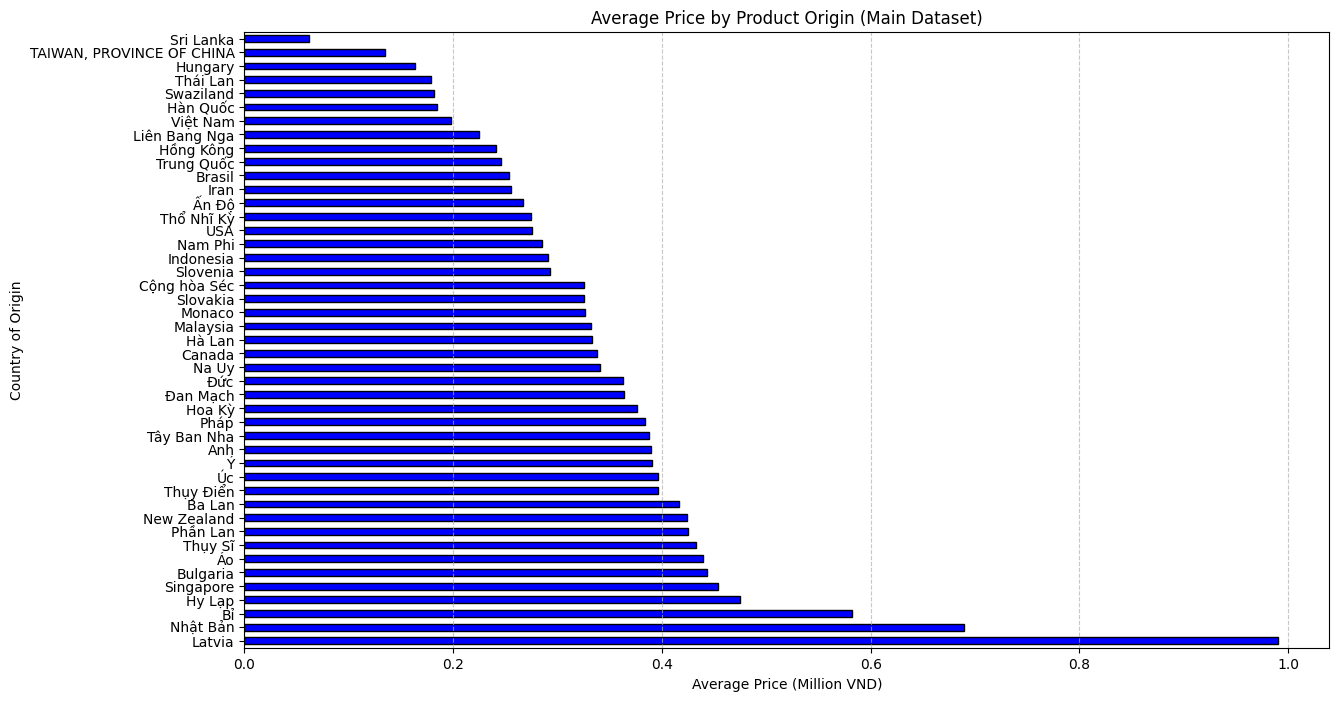

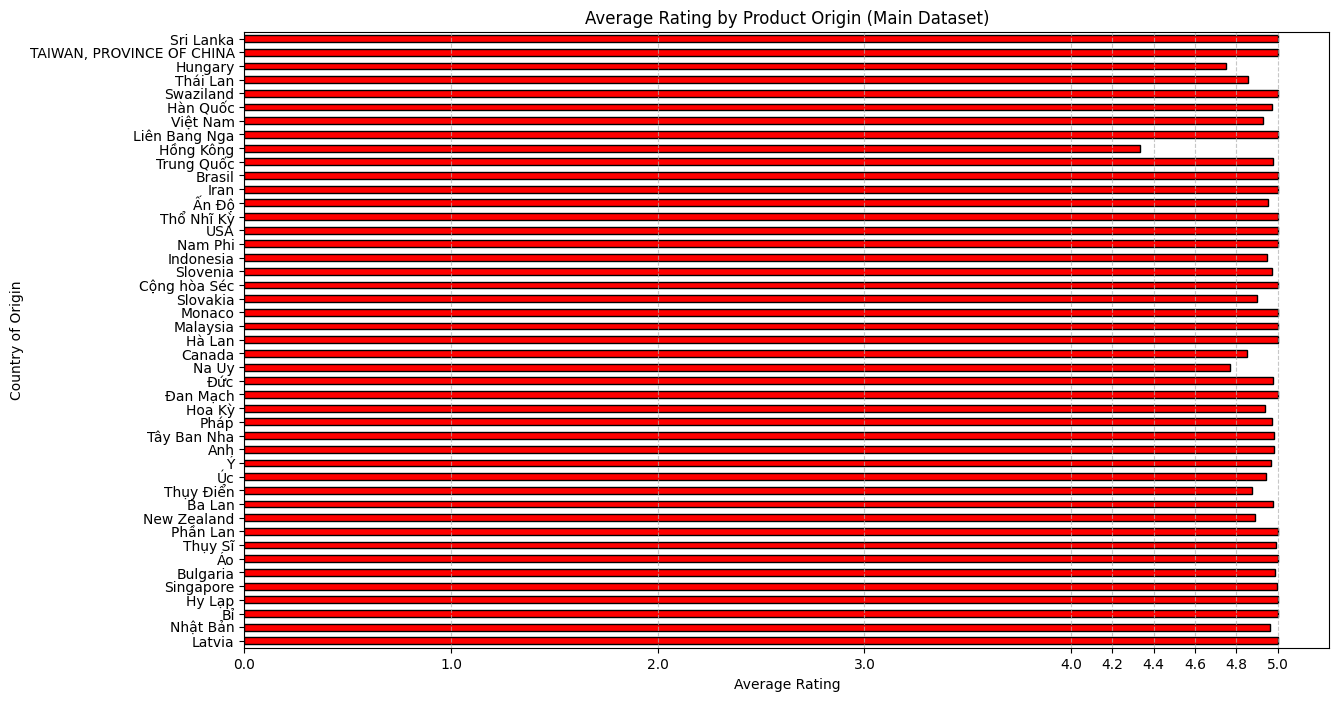

Index(['Latvia', 'Nhật Bản', 'Bỉ', 'Hy Lạp', 'Singapore', 'Bulgaria', 'Áo',
       'Thụy Sĩ', 'Phần Lan', 'New Zealand', 'Ba Lan', 'Thụy Điển', 'Úc', 'Ý',
       'Anh', 'Tây Ban Nha', 'Pháp', 'Hoa Kỳ', 'Đan Mạch', 'Đức', 'Na Uy',
       'Canada', 'Hà Lan', 'Malaysia', 'Monaco', 'Slovakia', 'Cộng hòa Séc',
       'Slovenia', 'Indonesia', 'Nam Phi', 'USA', 'Thổ Nhĩ Kỳ', 'Ấn Độ',
       'Iran', 'Brasil', 'Trung Quốc', 'Hồng Kông', 'Liên Bang Nga',
       'Việt Nam', 'Hàn Quốc', 'Swaziland', 'Thái Lan', 'Hungary',
       'TAIWAN, PROVINCE OF CHINA', 'Sri Lanka'],
      dtype='object', name='Country')

In [13]:
# Example usage for the main dataset
country_order = plot_average_by_origin_price(df, 'Average Price by Product Origin (Main Dataset)', 'Average Price (Million VND)')
plot_average_by_origin_rating(df, 'Average Rating by Product Origin (Main Dataset)', 'Average Rating', order=country_order)


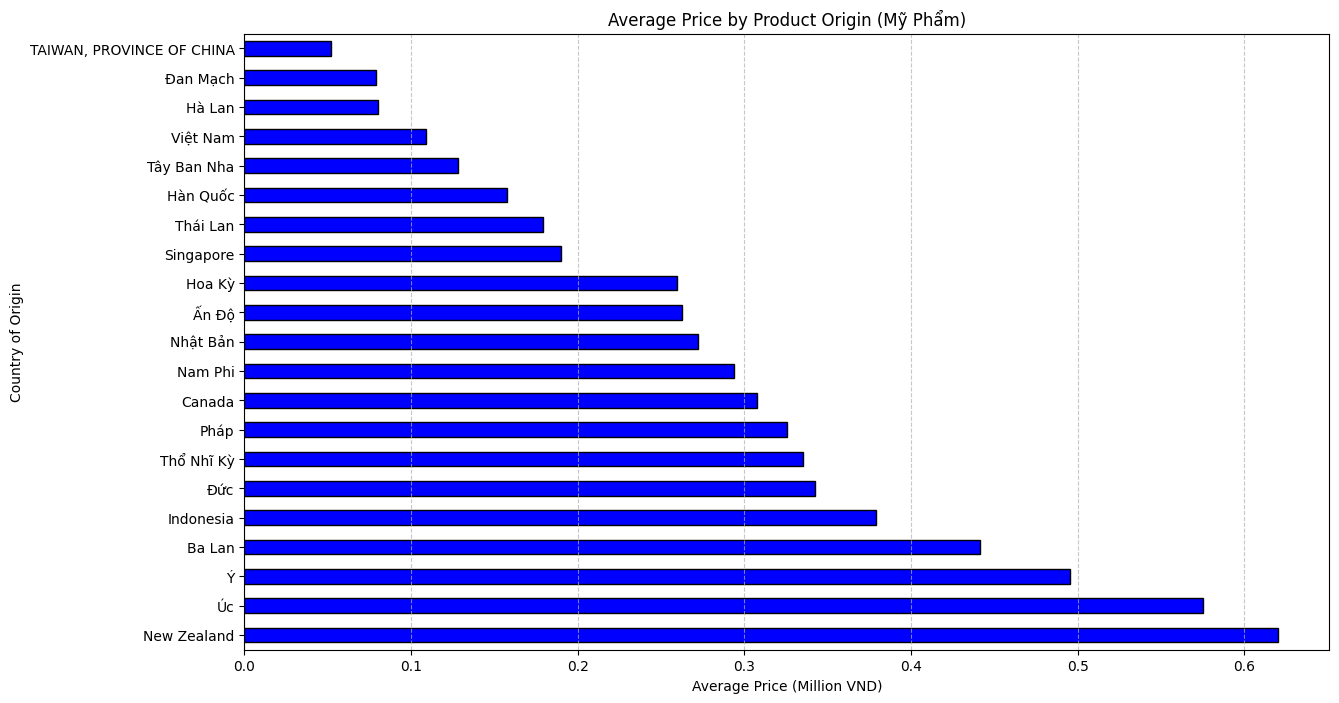

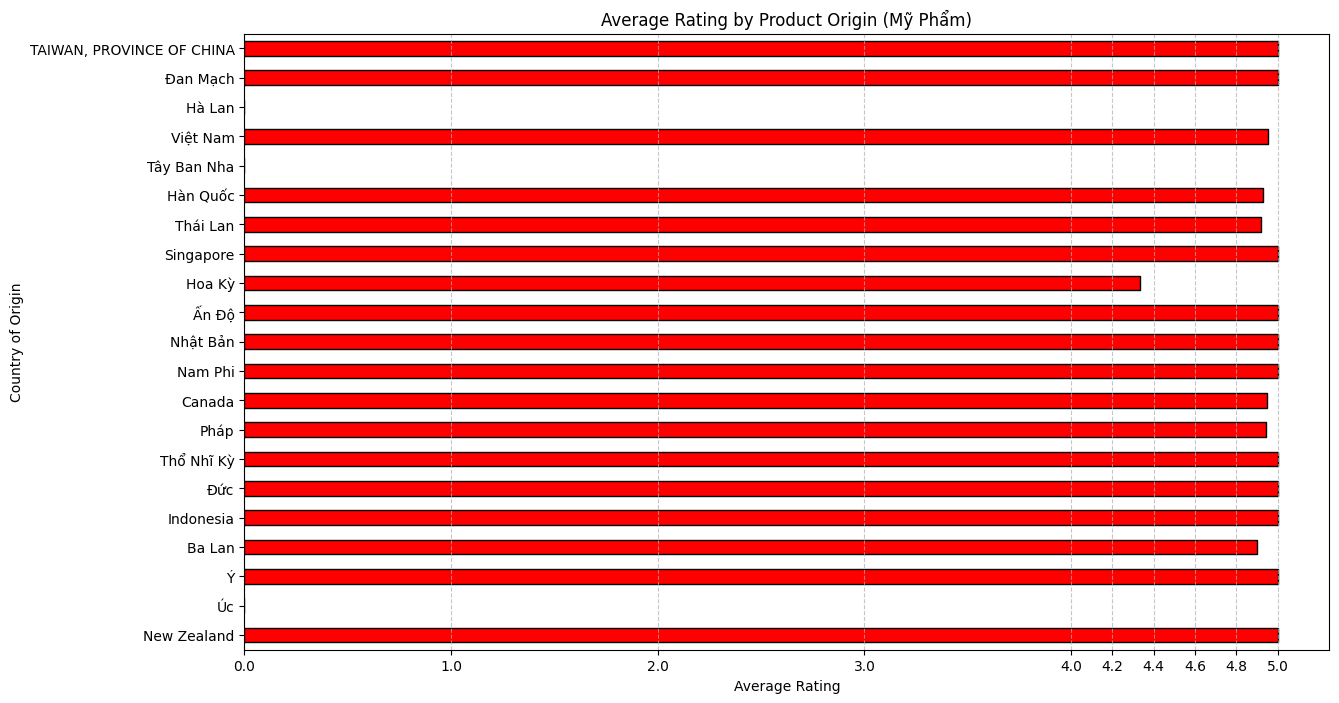

Index(['New Zealand', 'Úc', 'Ý', 'Ba Lan', 'Indonesia', 'Đức', 'Thổ Nhĩ Kỳ',
       'Pháp', 'Canada', 'Nam Phi', 'Nhật Bản', 'Ấn Độ', 'Hoa Kỳ', 'Singapore',
       'Thái Lan', 'Hàn Quốc', 'Tây Ban Nha', 'Việt Nam', 'Hà Lan', 'Đan Mạch',
       'TAIWAN, PROVINCE OF CHINA'],
      dtype='object', name='Country')

In [14]:
country_order_mypham = plot_average_by_origin_price(df_mypham, 'Average Price by Product Origin (Mỹ Phẩm)', 'Average Price (Million VND)')
plot_average_by_origin_rating(df_mypham, 'Average Rating by Product Origin (Mỹ Phẩm)', 'Average Rating', order=country_order_mypham)


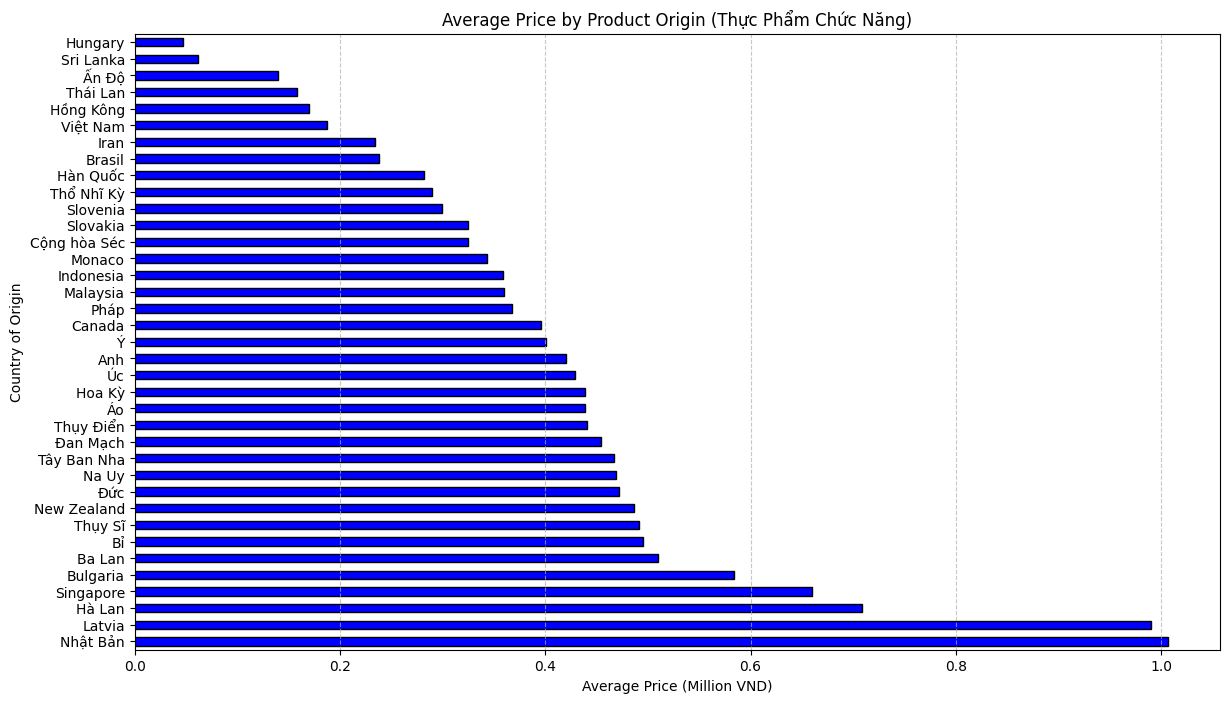

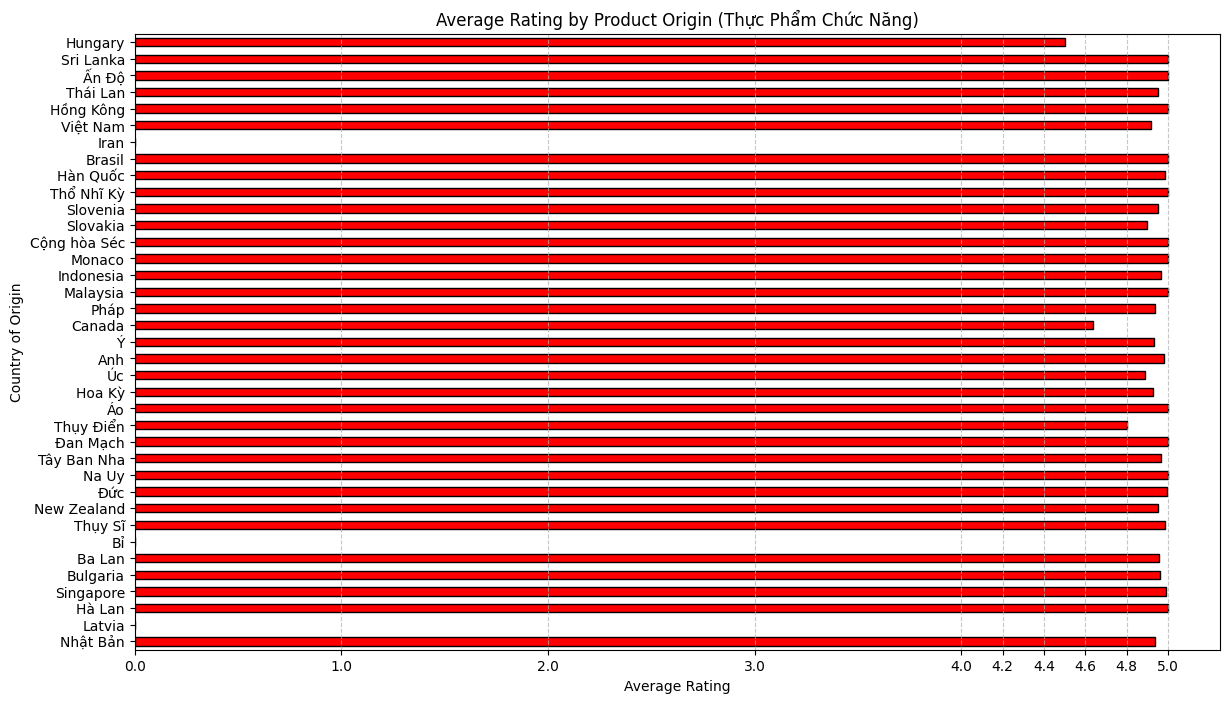

Index(['Nhật Bản', 'Latvia', 'Hà Lan', 'Singapore', 'Bulgaria', 'Ba Lan', 'Bỉ',
       'Thụy Sĩ', 'New Zealand', 'Đức', 'Na Uy', 'Tây Ban Nha', 'Đan Mạch',
       'Thụy Điển', 'Áo', 'Hoa Kỳ', 'Úc', 'Anh', 'Ý', 'Canada', 'Pháp',
       'Malaysia', 'Indonesia', 'Monaco', 'Cộng hòa Séc', 'Slovakia',
       'Slovenia', 'Thổ Nhĩ Kỳ', 'Hàn Quốc', 'Brasil', 'Iran', 'Việt Nam',
       'Hồng Kông', 'Thái Lan', 'Ấn Độ', 'Sri Lanka', 'Hungary'],
      dtype='object', name='Country')

In [15]:
# Example usage for Thực Phẩm Chức Năng dataset
country_order_tpcn = plot_average_by_origin_price(df_tpcn, 'Average Price by Product Origin (Thực Phẩm Chức Năng)', 'Average Price (Million VND)')
plot_average_by_origin_rating(df_tpcn, 'Average Rating by Product Origin (Thực Phẩm Chức Năng)', 'Average Rating', order=country_order_tpcn)

## Câu 2: Danh mục sản phẩm với các chức năng tổng quan được sản xuất nhiều ở các châu lục nào? Những thương hiệu nổi tiếng nào gắn liền với các quốc gia hàng đầu trong châu lục? 


##### Tổng quan
- Dữ liệu phân tích cho thấy phần lớn các danh mục sản phẩm thực phẩm chức năng và mỹ phẩm tại Long Châu được nhập khẩu từ Châu Á, tiếp theo là Châu Âu, và một phần nhỏ đến từ Châu Mỹ, Châu Phi, cũng như các châu lục khác. Châu Á chiếm ưu thế nhờ vị trí địa lý gần Việt Nam, giảm chi phí vận chuyển, thời gian cung ứng và phù hợp với thị hiếu của người tiêu dùng.
##### Chi tiết:
- Danh mục kem chống nắng cho thấy sự cân bằng giữa sản phẩm từ Châu Á và Châu Âu, phản ánh nhu cầu đa dạng từ người tiêu dùng. 
    + Châu Á, với các sản phẩm đến từ Indonesia, dẫn đầu trong việc cung cấp các sản phẩm hiệu quả với giá cả phải chăng, phù hợp với thời tiết và làn da người Việt. 
    + Trong khi đó, sản phẩm từ Pháp – quốc gia đi đầu trong ngành công nghiệp mỹ phẩm tại Châu Âu – chiếm tỷ lệ lớn nhờ chất lượng cao và thương hiệu uy tín
- Trong danh mục sản phẩm hỗ trợ làm đẹp, Châu Á và Châu Mỹ có số lượng sản phẩm tương đương. 
    + Châu Á, với Việt Nam và Nhật Bản chiếm tỷ trọng lớn nhất, sau đó là Thái Lan đã mang đến các sản phẩm làm đẹp kết hợp giữa giải pháp truyền thống và hiện đại. Điều này giúp các sản phẩm của Châu Á trở nên phổ biến hơn với người tiêu dùng trong nước nhờ phù hợp thị hiếu và phù hợp với văn hóa làm đẹp tại Việt Nam. 
    + Các sản phẩm từ Châu Mỹ, chủ yếu đến từ Hoa Kỳ và Canada.Và Hoa Kỳ là quốc gia dẫn đầu về số lượng sản phẩm trong danh mục này. Điều này phản ánh vai trò quan trọng của Hoa Kỳ trong ngành công nghiệp làm đẹp toàn cầu, với các thương hiệu lớn tập trung vào công nghệ tiên tiến, hiệu quả sản phẩm, và sự đa dạng trong phân khúc thị trường dẫn đến đáp ứng được mọi phân khúc khách hàng.
##### Kết luận:
- Danh mục Kem chống nắng cho thấy sự phân hóa thị trường rõ ràng giữa Châu Á và Châu Âu (Indonesia và Pháp)
- Danh mục Hỗ trợ làm đẹp thể hiện sự vượt trội của Hoa Kỳ trong ngành công nghiệp làm đẹp, nhưng Châu Á vẫn giữ vị trí quan trọng với các giải pháp phù hợp với thị hiếu nội địa. Xu hướng này chỉ ra rằng người tiêu dùng Việt Nam ngày càng có sự lựa chọn đa dạng hơn, từ các thương hiệu quốc tế đến sản phẩm địa phương.

<Figure size 1200x800 with 0 Axes>

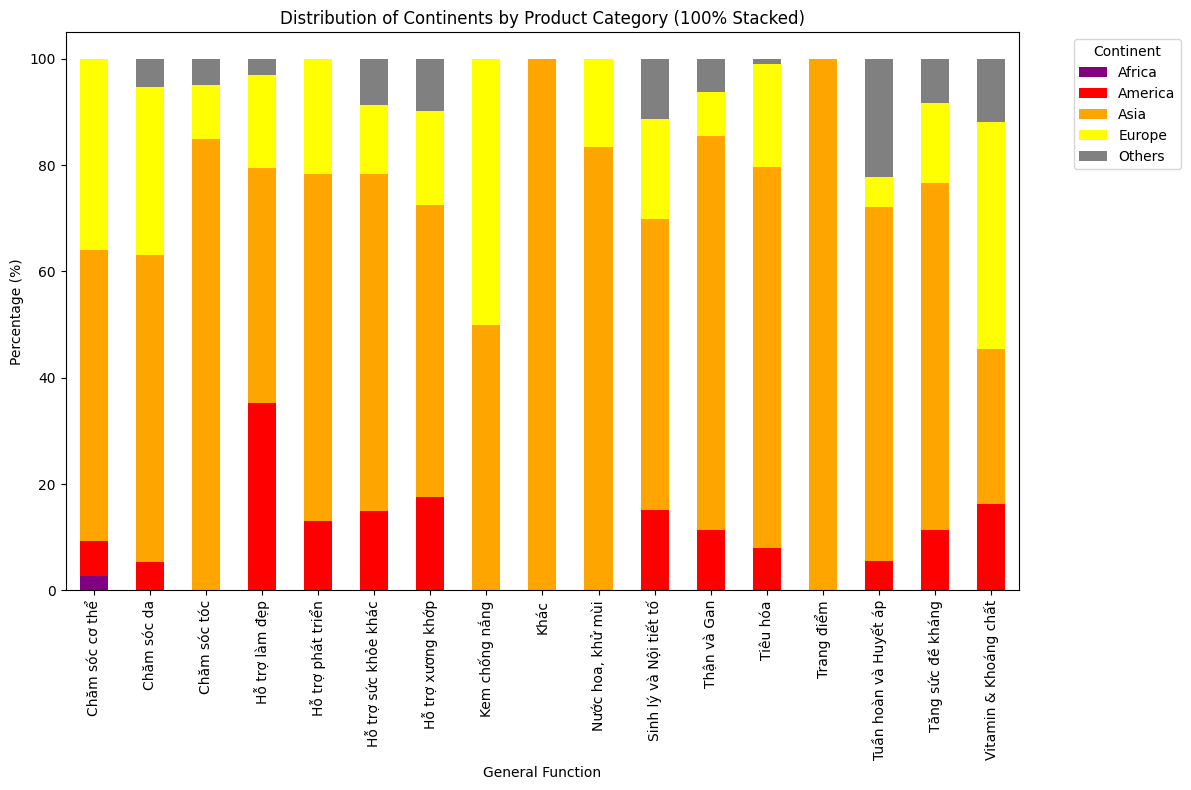

In [16]:
function_continent_counts = df_pr.groupby(['General_Function', 'Continent']).size().unstack(fill_value=0)

function_continent_percent = function_continent_counts.div(function_continent_counts.sum(axis=1), axis=0) * 100

custom_colors = ["purple", "red", "orange", "yellow", "grey"]

plt.figure(figsize=(12, 8))
function_continent_percent.plot(kind='bar', stacked=True, color=custom_colors, figsize=(12, 8))
plt.title("Distribution of Continents by Product Category (100% Stacked)")
plt.xlabel("General Function")
plt.ylabel("Percentage (%)")
plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Chọn dạng biểu đồ phù hợp để visualization (python)
Vẽ biểu đồ kem chống nắng của châu á và châu âu (feature: Country, general function = Kem chống nắng, Continent)
Vẽ biểu đồ hỗ trợ làm đẹp của châu á và châu mỹ (feature: Country, general function = Hỗ trợ làm đẹp,Continent )

Data loaded successfully!


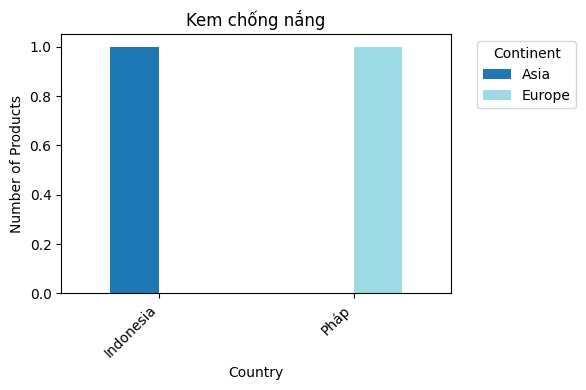

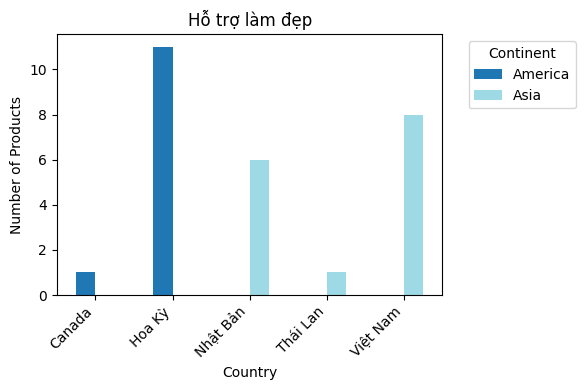

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = './Data/MyPham_TPCN_data(processed).csv'  
try:
    data = pd.read_csv(file_path)
    print("Data loaded successfully!")
except FileNotFoundError:
    print("Error: File not found. Please check the file path.")
    raise

# Corrected function call with exact column name
def plot_grouped_bar_chart(data, general_function, continents, title):
    # Filter data by general function and continent
    filtered_data = data[
        (data['General_Function'] == general_function) & 
        (data['Continent'].isin(continents))
    ]
    # Group by Country and Continent, count occurrences
    grouped_data = filtered_data.groupby(['Continent', 'Country']).size().unstack(fill_value=0)
    
    # Plot grouped bar chart
    grouped_data.T.plot(kind='bar', figsize=(6, 4), colormap='tab20')
    plt.title(title)
    plt.xlabel("Country")
    plt.ylabel("Number of Products")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Plot 1: Kem chống nắng - Châu Á và Châu Âu
plot_grouped_bar_chart(
    data, 
    general_function="Kem chống nắng", 
    continents=["Asia", "Europe"], 
    title="Kem chống nắng"
)

# Plot 2: Hỗ trợ làm đẹp - Châu Á và Châu Mỹ
plot_grouped_bar_chart(
    data, 
    general_function="Hỗ trợ làm đẹp", 
    continents=["Asia", "America"], 
    title="Hỗ trợ làm đẹp"
)

## Câu 3: Trong từng danh mục mỹ phẩm và thực phẩm chức năng, quốc gia nào chiếm thị phần cao nhất, và điều này cho thấy xu hướng cung ứng ra sao?

### Mỹ phẩm
- **Chăm sóc cơ thể**: Việt Nam có cột cao nhất trong danh mục này, cho thấy các sản phẩm chăm sóc cơ thể nội địa chiếm ưu thế trên thị trường.
- **Chăm sóc tóc - da đầu**: Hàn Quốc có cột cao nhất, phản ánh sức mạnh của ngành chăm sóc tóc Hàn Quốc.
- **Chống nắng toàn thân**: Hoa Kỳ nổi bật với cột cao nhất trong danh mục chống nắng, cho thấy người tiêu dùng tin tưởng vào sản phẩm từ Hoa Kỳ.
- **Da bị kích ứng**: Việt Nam dẫn đầu với cột cao nhất, có thể vì các sản phẩm nội địa phù hợp với nhu cầu đặc thù của làn da nhạy cảm ở Việt Nam.

### Thực phẩm chức năng
- **Thận, tiền liệt tuyến**: Anh có cột cao nhất, cho thấy người tiêu dùng ưa chuộng các sản phẩm sức khỏe từ Anh với tiêu chuẩn chất lượng cao.
- **Tăng sức đề kháng, miễn dịch**: Việt Nam có cột cao nhất, phản ánh xu hướng tiêu dùng các sản phẩm tăng cường miễn dịch nội địa.
- **Bổ sung Canxi & Vitamin D**: Úc và Nhật Bản đều có cột cao trong danh mục này, phản ánh niềm tin vào sản phẩm bổ sung từ hai quốc gia này.
- **Vitamin & Khoáng chất**: Úc dẫn đầu với cột cao nhất trong danh mục vitamin, tiếp tục củng cố vị thế của mình trong lĩnh vực bổ sung sức khỏe.

### Nhận xét xu hướng cung ứng
- **Việt Nam** dẫn đầu trong nhiều danh mục mỹ phẩm và thực phẩm chức năng trong nhà thuốc Long Châu, đặc biệt là chăm sóc cơ thể và tăng cường miễn dịch, cho thấy sự ưa chuộng sản phẩm nội địa.
- **Hàn Quốc**, **Hoa Kỳ**, **Úc**, và **Anh** chiếm ưu thế trong các danh mục mà quốc gia của họ nổi tiếng, như chăm sóc tóc (Hàn Quốc) và bổ sung sức khỏe (Úc, Anh), thể hiện sự tin cậy vào sản phẩm nhập khẩu chuyên biệt.




In [18]:
def plot_category_country_distribution(df, category_name):
    # Nhóm dữ liệu theo 'Category' và 'Country' để đếm số lượng
    category_country_df = df.groupby(['Category', 'Country']).size().reset_index(name='Count')
    
    # Xoay dữ liệu sao cho 'Category' là index và các quốc gia trong 'Country' là các cột
    category_country_pivot = category_country_df.pivot(index='Category', columns='Country', values='Count').fillna(0)
    
    # Vẽ biểu đồ thanh chồng
    plt.figure(figsize=(15, 10))
    category_country_pivot.plot(kind='bar', stacked=True, colormap='Spectral', width=0.7, figsize=(15, 10))
    
    # Thêm nhãn và tựa đề cho biểu đồ
    plt.title(f"Thị phần quốc gia trong từng danh mục {category_name}", fontsize=20, pad=20)
    plt.xlabel("Phân loại", fontsize=14)
    plt.ylabel("Số lượng sản phẩm", fontsize=14)
    plt.legend(title="Quốc gia", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


<Figure size 1500x1000 with 0 Axes>

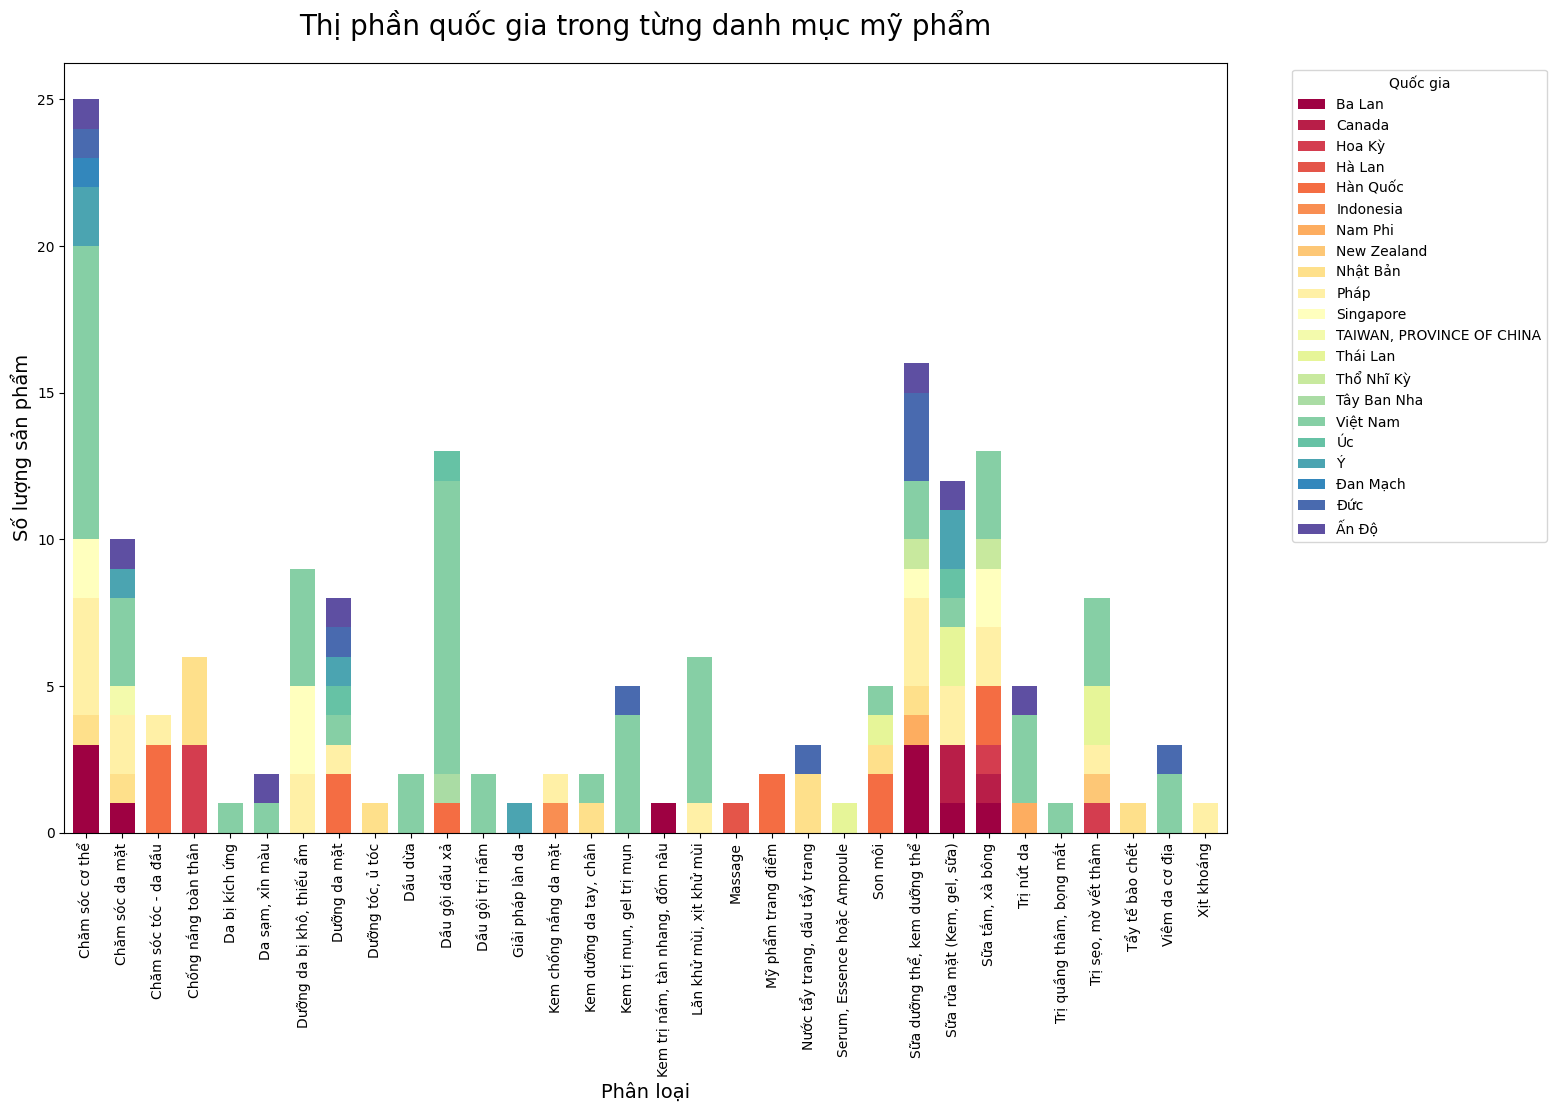

<Figure size 1500x1000 with 0 Axes>

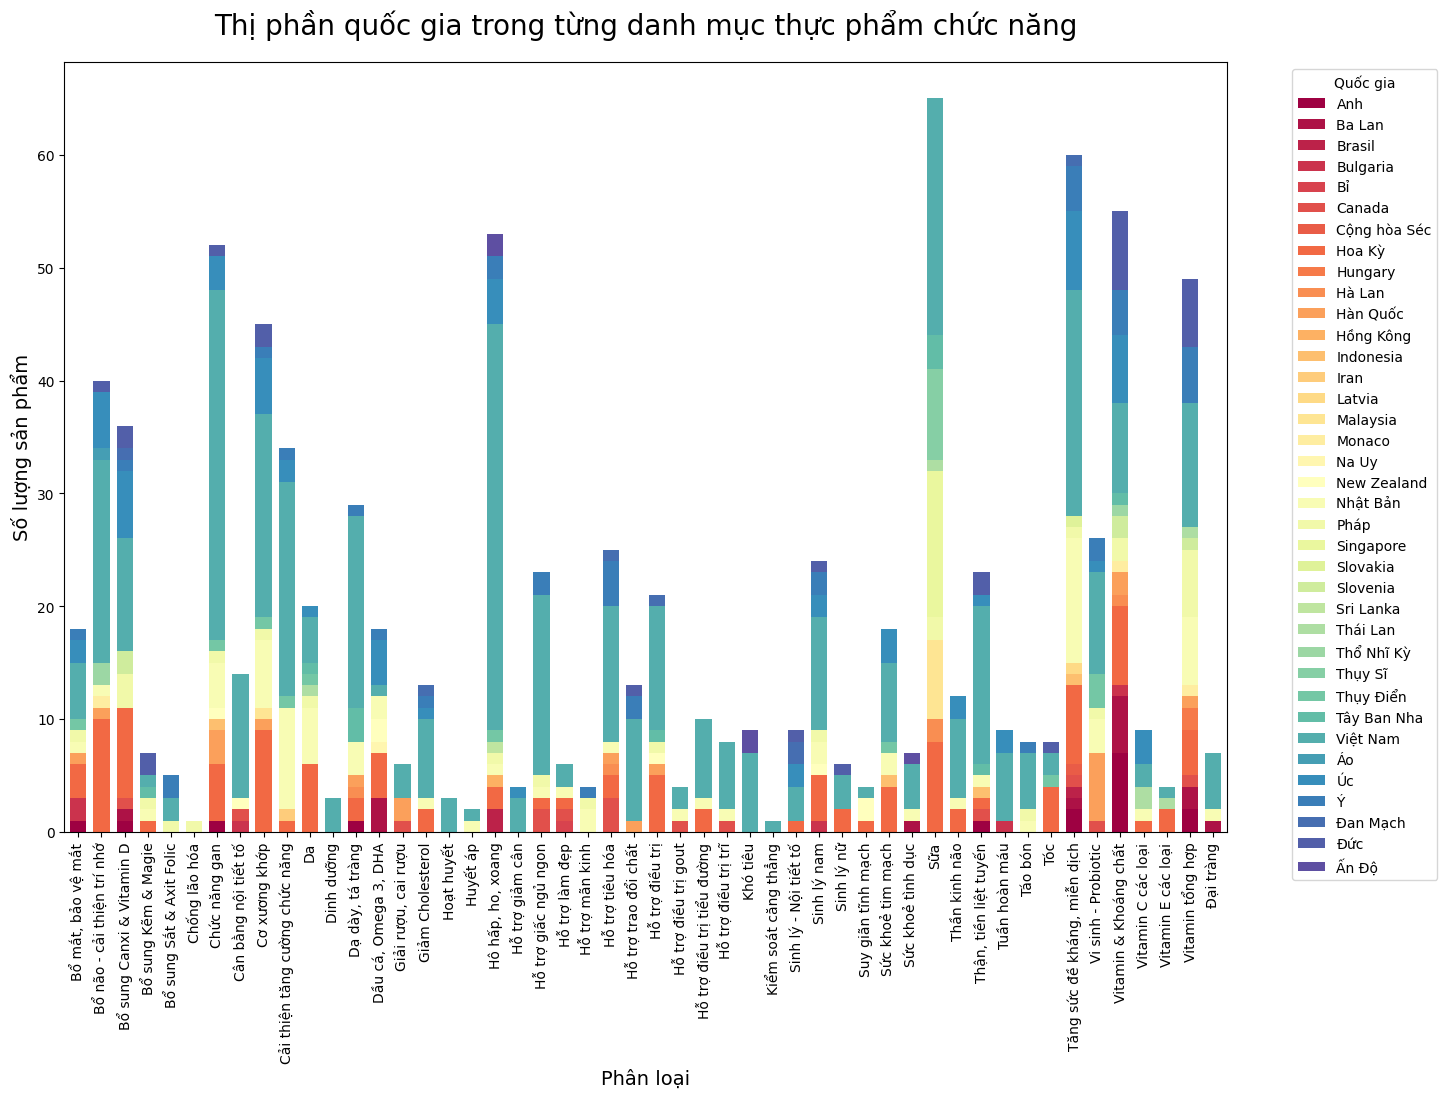

In [19]:
plot_category_country_distribution(df_mypham, "mỹ phẩm")
plot_category_country_distribution(df_tpcn, "thực phẩm chức năng")

## Câu 4: Giá cả ảnh hưởng như thế nào đến đánh giá của sản phẩm?

In [20]:
def plot_price_rating_relationship(data, title):
    # Bỏ các hàng có giá trị bị thiếu trong 'Price' hoặc 'Rating'
    filtered_data = data.dropna(subset=['Price', 'Rating'])
    x = filtered_data['Rating']
    y = filtered_data['Price'] / 1e6  # Chuyển đơn vị giá sang triệu VNĐ để dễ đọc
    
    plt.figure(figsize=(12, 6))
    
    # Vẽ biểu đồ scatter
    scatter = plt.scatter(x, y, c=x, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter, label='Rating')  # Thanh màu biểu thị mức Rating
    
    # Tạo đường xu hướng
    z = np.polyfit(x, y, 1)  # Fit đường xu hướng tuyến tính
    p = np.poly1d(z)
    plt.plot(x, p(x), color='red', linestyle='-', label='Đường xu hướng')
    
    # Tiêu đề và nhãn trục
    plt.title(title, pad=20)
    plt.xlabel('Rating')
    plt.ylabel('Price (triệu VNĐ)')
    
    # Tùy chỉnh ticks (giá trị hiển thị trên trục)
    plt.grid(True)
    plt.xticks(np.arange(0, 5.1, 0.5)) 
    plt.xlim(x.min() - 0.1, x.max() + 0.1)
    plt.ylim(y.min() - 0.1, y.max() + 0.1)
    #plt.yticks([1, 2, 3, 4, 5, 6], ['1M', '2M', '3M', '4M', '5M', '6M'])
    
    plt.legend()  # Hiển thị chú thích
    plt.show()

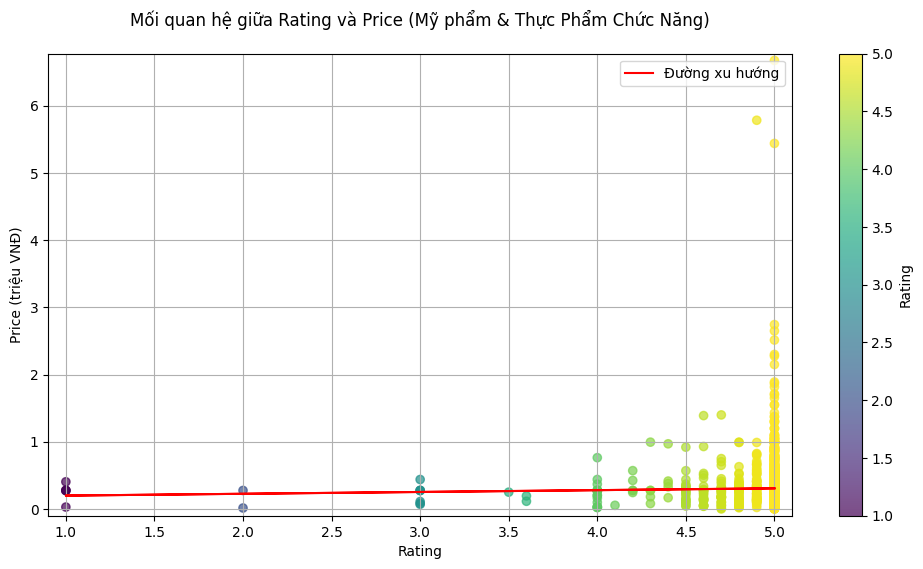

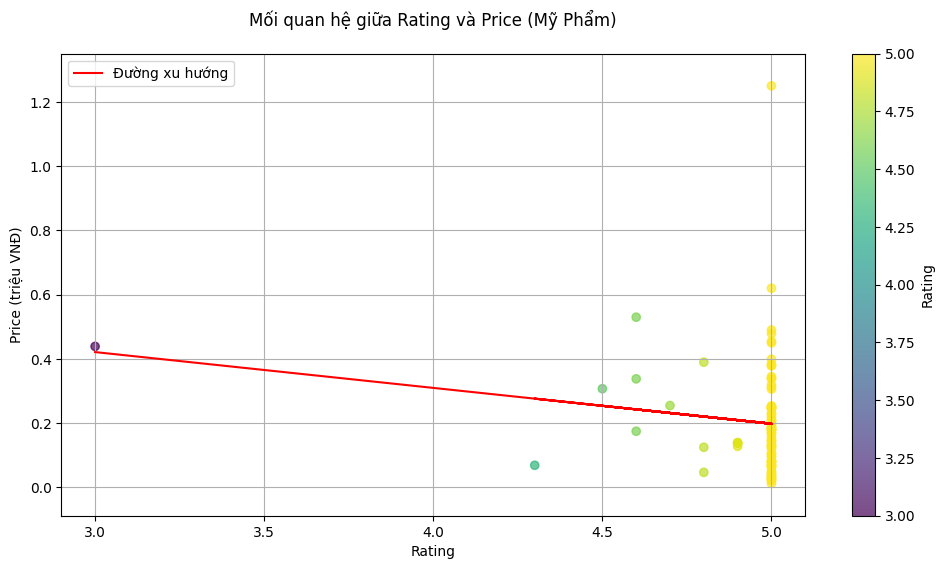

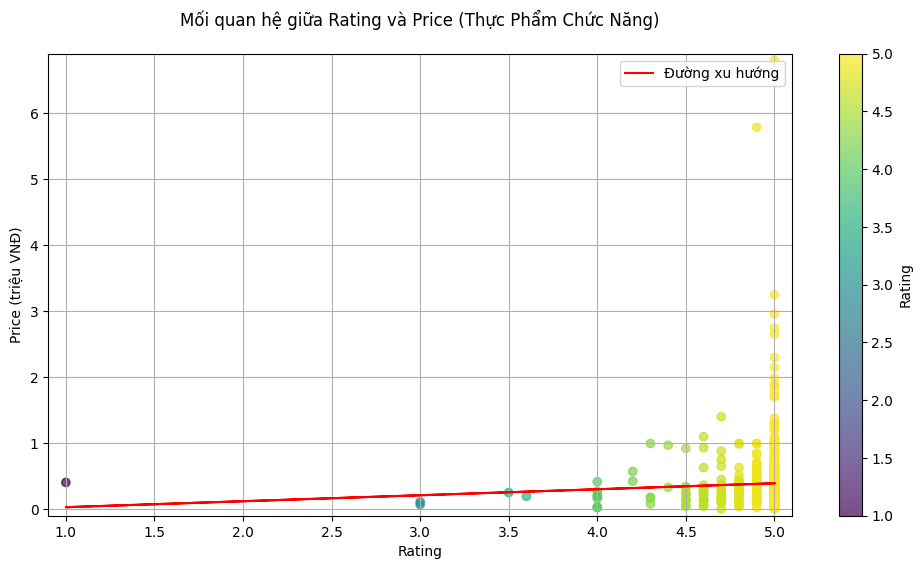

In [21]:
plot_price_rating_relationship(df, 'Mối quan hệ giữa Rating và Price (Mỹ phẩm & Thực Phẩm Chức Năng)')
plot_price_rating_relationship(df_mypham, 'Mối quan hệ giữa Rating và Price (Mỹ Phẩm)')
plot_price_rating_relationship(df_tpcn, 'Mối quan hệ giữa Rating và Price (Thực Phẩm Chức Năng)')

Biểu đồ cho thấy giá và rating không liên quan chặt chẽ với nhau. Dù giá cao hay thấp, rating vẫn tập trung trong khoảng 4.0 - 5.0. Một số sản phẩm giá rất cao nhưng rating không nhỉnh hơn nhiều so với sản phẩm rẻ hơn. Điều này gợi ý rằng người dùng không chỉ dựa vào giá để đánh giá sản phẩm; các yếu tố khác như chất lượng hay thương hiệu có thể quan trọng hơn.

## Câu 4.1

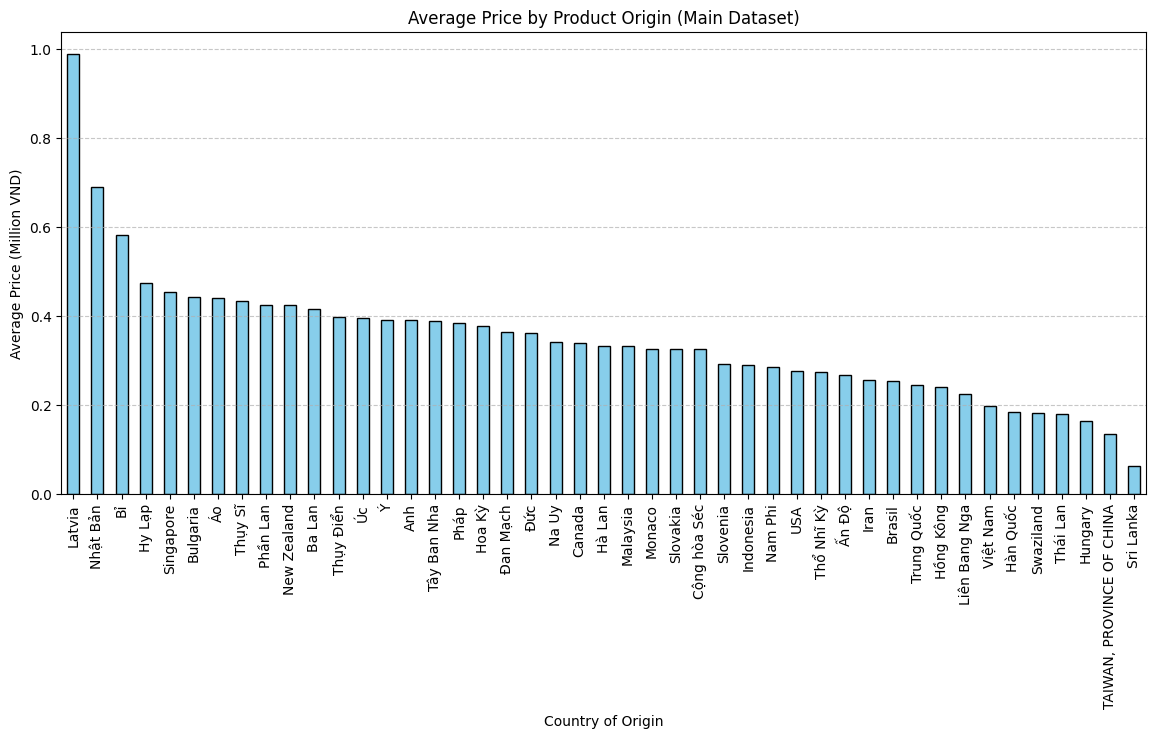

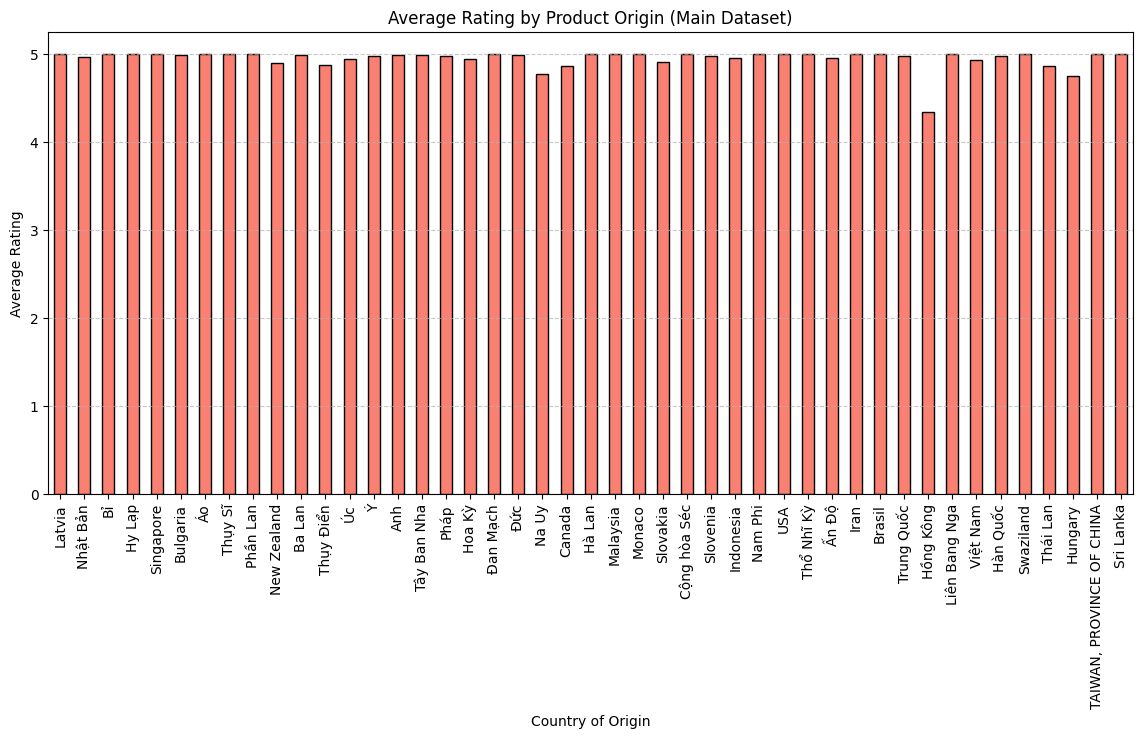

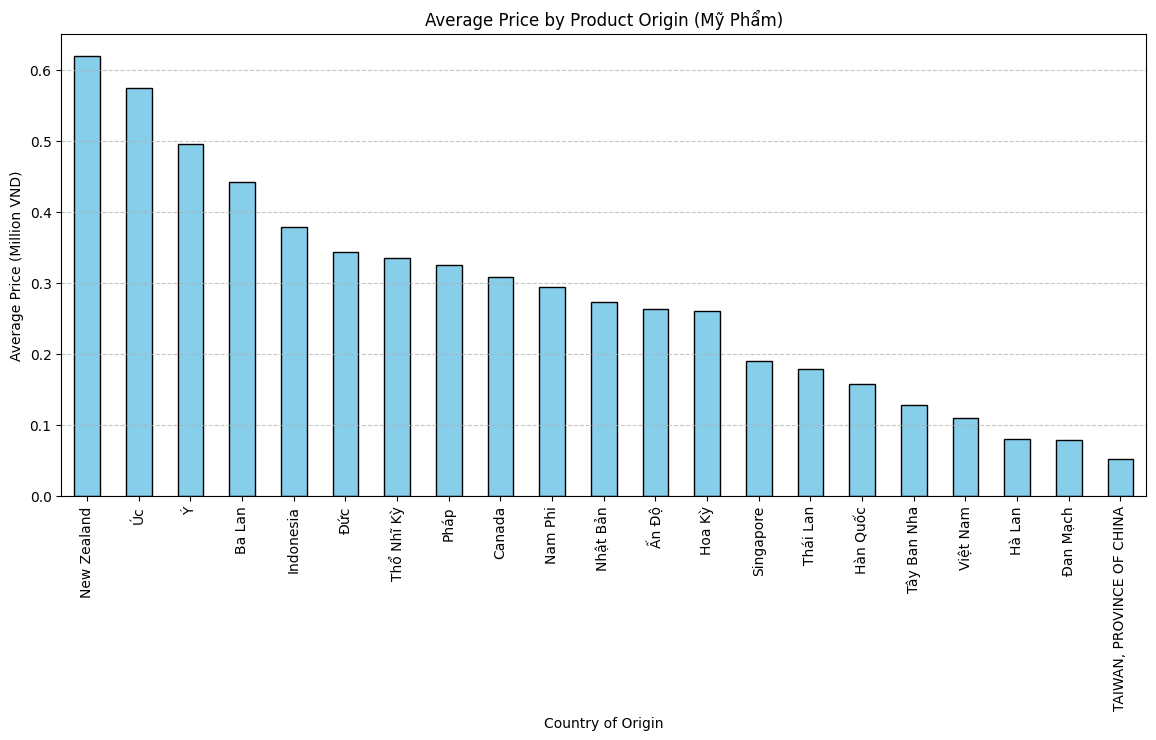

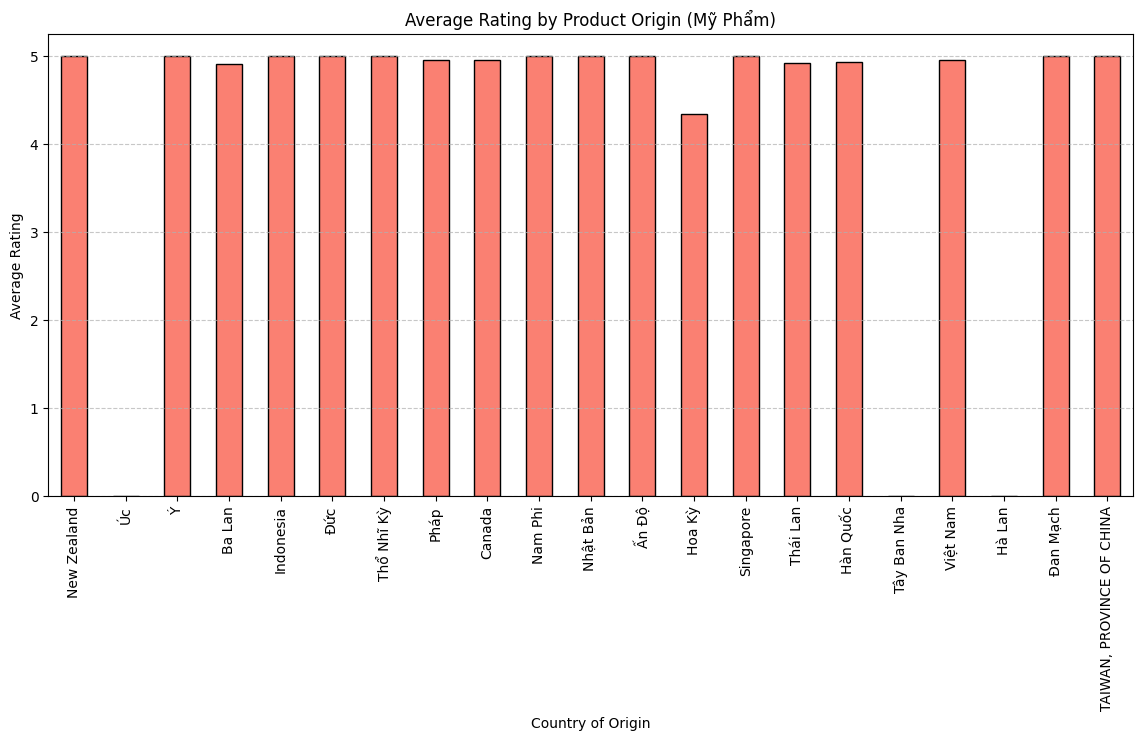

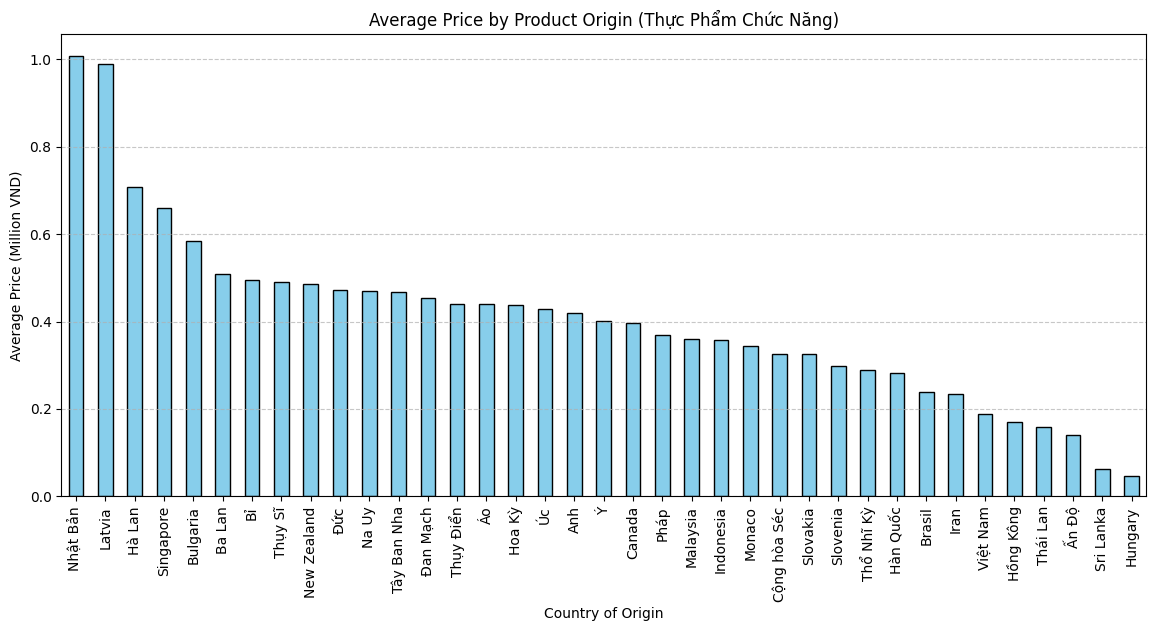

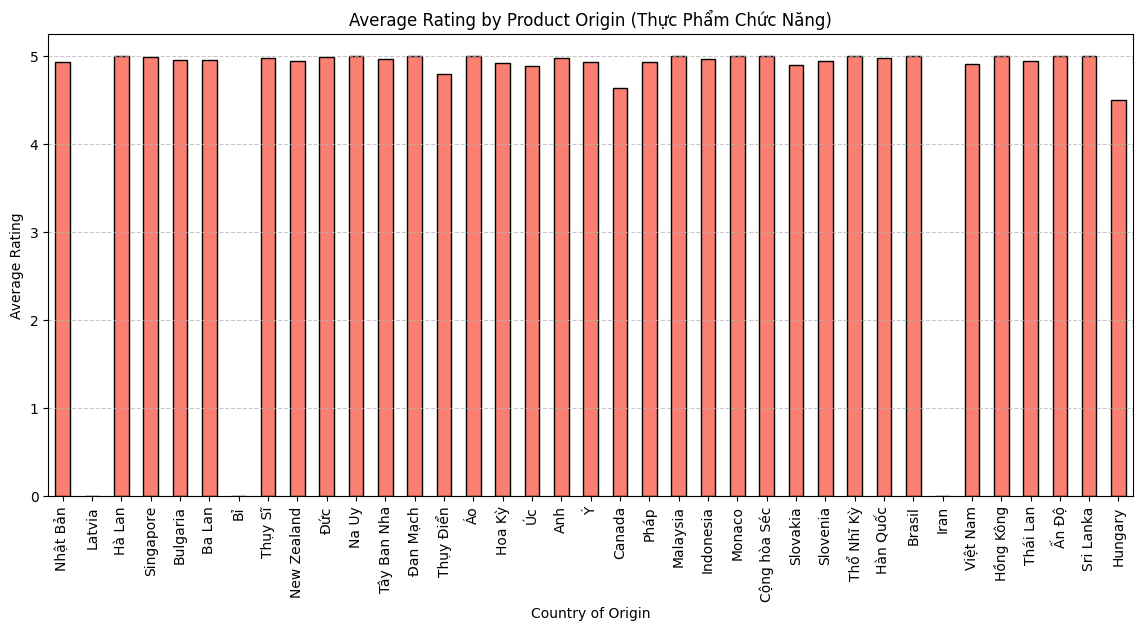

Index(['Nhật Bản', 'Latvia', 'Hà Lan', 'Singapore', 'Bulgaria', 'Ba Lan', 'Bỉ',
       'Thụy Sĩ', 'New Zealand', 'Đức', 'Na Uy', 'Tây Ban Nha', 'Đan Mạch',
       'Thụy Điển', 'Áo', 'Hoa Kỳ', 'Úc', 'Anh', 'Ý', 'Canada', 'Pháp',
       'Malaysia', 'Indonesia', 'Monaco', 'Cộng hòa Séc', 'Slovakia',
       'Slovenia', 'Thổ Nhĩ Kỳ', 'Hàn Quốc', 'Brasil', 'Iran', 'Việt Nam',
       'Hồng Kông', 'Thái Lan', 'Ấn Độ', 'Sri Lanka', 'Hungary'],
      dtype='object', name='Country')

In [22]:
def plot_average_by_origin_aligned(data, value_column, title, ylabel, order=None):
    """
    Plots the average values of a specified column (e.g., Price or Rating) by product origin
    with consistent country ordering.

    Parameters:
    - data: DataFrame containing the data to be plotted
    - value_column: Column name for the values to be averaged and plotted
    - title: Title for the plot
    - ylabel: Label for the y-axis
    - order: Optional list to specify consistent order of countries
    """
    # Calculate the average value by country
    origin_analysis = data.groupby('Country')[value_column].mean()
    if value_column == 'Price':
        origin_analysis /= 1e6  # Convert Price to millions if applicable
    
    # Align data to the specified order
    if order is not None:
        origin_analysis = origin_analysis.reindex(order)
    else:
        origin_analysis = origin_analysis.sort_values(ascending=False)
        order = origin_analysis.index  # Save the order for subsequent calls

    # Plot the average value by country
    plt.figure(figsize=(14, 6))
    origin_analysis.plot(kind='bar', color='skyblue' if value_column == 'Price' else 'salmon', edgecolor='black')
    plt.title(title)
    plt.xlabel('Country of Origin')
    plt.ylabel(ylabel)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    return order  # Return the order for use in the next plot

# First, plot for the main dataset (df) and obtain the order of countries
country_order = plot_average_by_origin_aligned(df, 'Price', 'Average Price by Product Origin (Main Dataset)', 'Average Price (Million VND)')

# Use the same country order for subsequent plots
plot_average_by_origin_aligned(df, 'Rating', 'Average Rating by Product Origin (Main Dataset)', 'Average Rating', order=country_order)

# Repeat for Mỹ Phẩm dataset (df_mypham) with consistent country order
country_order_mypham = plot_average_by_origin_aligned(df_mypham, 'Price', 'Average Price by Product Origin (Mỹ Phẩm)', 'Average Price (Million VND)')
plot_average_by_origin_aligned(df_mypham, 'Rating', 'Average Rating by Product Origin (Mỹ Phẩm)', 'Average Rating', order=country_order_mypham)

# Repeat for Thực Phẩm Chức Năng dataset (df_tpcn) with consistent country order
country_order_tpcn = plot_average_by_origin_aligned(df_tpcn, 'Price', 'Average Price by Product Origin (Thực Phẩm Chức Năng)', 'Average Price (Million VND)')
plot_average_by_origin_aligned(df_tpcn, 'Rating', 'Average Rating by Product Origin (Thực Phẩm Chức Năng)', 'Average Rating', order=country_order_tpcn)


## Câu 5: Dạng nào thì được ưa chuộng, dễ sử dụng hơn theo danh mục?

In [23]:
pd.set_option('display.max_rows', 1000)
df_tpcn['Category'].unique()

array(['Thận, tiền liệt tuyến', 'Tăng sức đề kháng, miễn dịch',
       'Bổ sung Canxi & Vitamin D', 'Vitamin & Khoáng chất',
       'Cải thiện tăng cường chức năng', 'Bổ não - cải thiện trí nhớ',
       'Bổ mắt, bảo vệ mắt', 'Tuần hoàn máu', 'Cơ xương khớp',
       'Hô hấp, ho, xoang', 'Hỗ trợ làm đẹp', 'Chức năng gan',
       'Thần kinh não', 'Giải rượu, cai rượu', 'Vi sinh - Probiotic',
       'Dạ dày, tá tràng', 'Hỗ trợ trao đổi chất',
       'Bổ sung Sắt & Axit Folic', 'Táo bón', 'Cân bằng nội tiết tố',
       'Vitamin tổng hợp', 'Đại tràng', 'Hỗ trợ điều trị trĩ',
       'Sinh lý nữ', 'Hỗ trợ giấc ngủ ngon', 'Giảm Cholesterol', 'Da',
       'Dầu cá, Omega 3, DHA', 'Tóc', 'Hỗ trợ điều trị',
       'Hỗ trợ tiêu hóa', 'Sinh lý nam', 'Khó tiêu',
       'Hỗ trợ điều trị tiểu đường', 'Vitamin E các loại',
       'Sức khoẻ tim mạch', 'Chống lão hóa', 'Bổ sung Kẽm & Magie',
       'Hỗ trợ điều trị gout', 'Sức khoẻ tình dục', 'Hỗ trợ giảm cân',
       'Sinh lý - Nội tiết tố', 'Vitamin C cá

In [24]:
df_mypham['Dosage Form'].unique()

array(['Gel', 'Dạng bọt', 'Dung dịch', 'Dạng sáp', 'Dạng kem',
       'Miếng dán', 'Nhũ tương (Gel)', 'Nhũ dịch dầu trong nước',
       'Dạng xịt', 'Dạng dầu', 'Serum', 'Kem', 'Kem bôi da', 'Cao',
       'Lotion bôi da'], dtype=object)

In [25]:
def classify_general_function_cosmetics(category):
    body_care = ['Chăm sóc cơ thể', 'Sữa tắm, xà bông', 'Sữa dưỡng thể, kem dưỡng thể', 'Dưỡng da bị khô, thiếu ẩm',
                 'Kem dưỡng da tay, chân', 'Chống nắng toàn thân', 'Trị nứt da', 'Massage']
    
    hair_care = ['Dầu gội dầu xả', 'Chăm sóc tóc - da đầu', 'Dưỡng tóc, ủ tóc', 'Dầu gội trị nấm']
    
    skin_care = ['Chăm sóc da mặt', 'Kem trị mụn, gel trị mụn', 'Trị sẹo, mờ vết thâm', 'Tẩy tế bào chết', 'Dưỡng da mặt',
                 'Da sạm, xỉn màu', 'Nước tẩy trang, dầu tẩy trang', 'Sữa rửa mặt (Kem, gel, sữa)', 
                 'Viêm da cơ địa', 'Serum, Essence hoặc Ampoule', 'Xịt khoáng', 'Da bị kích ứng',
                 'Giải pháp làn da', 'Trị quầng thâm, bọng mắt', 'Kem trị nám, tàn nhang, đốm nâu']
    
    makeup = ['Son môi', 'Mỹ phẩm trang điểm']
    
    fragrance = ['Lăn khử mùi, xịt khử mùi']
    
    sun_protection = ['Kem chống nắng da mặt']

    if category in body_care:
        return 'Chăm sóc cơ thể'
    elif category in hair_care:
        return 'Chăm sóc tóc'
    elif category in skin_care:
        return 'Chăm sóc da'
    elif category in makeup:
        return 'Trang điểm'
    elif category in fragrance:
        return 'Nước hoa, khử mùi'
    elif category in sun_protection:
        return 'Kem chống nắng'
    else:
        return 'Khác'
    
    
def classify_general_function_supplements(category):
    """
    Hàm phân loại chức năng chung của sản phẩm TPCN.

    Tham số:
    category : Danh mục sản phẩm ban đầu.

    Trả về:
    Chức năng chung của sản phẩm.
    """
    immune_support = ['Tăng sức đề kháng, miễn dịch', 'Cải thiện tăng cường chức năng', 'Hỗ trợ giấc ngủ ngon', 'Giảm Cholesterol', 'Chống lão hóa', 'Hỗ trợ mãn kinh', 'Sức khoẻ tim mạch', 'Sức khoẻ tình dục']
    vitamin_mineral = ['Vitamin & Khoáng chất', 'Bổ sung Canxi & Vitamin D', 'Vitamin tổng hợp', 'Vitamin E các loại', 'Vitamin C các loại', 'Bổ sung Kẽm & Magie', 'Dầu cá, Omega 3, DHA']
    liver_kidney = ['Thận, tiền liệt tuyến', 'Chức năng gan', 'Gan, mật', 'Giải rượu, cai rượu', 'Hỗ trợ điều trị tiểu đường', 'Hỗ trợ điều trị gout']
    digestive_health = ['Hỗ trợ tiêu hóa', 'Dạ dày, tá tràng', 'Táo bón', 'Đại tràng', 'Hỗ trợ điều trị trĩ', 'Khó tiêu', 'Vi sinh - Probiotic']
    growth_support = ['Cải thiện chiều cao', 'Tăng cân', 'Dinh dưỡng', 'Sữa']
    beauty_support = ['Hỗ trợ làm đẹp', 'Da', 'Tóc']
    circulatory_support = ['Tuần hoàn máu', 'Hoạt huyết', 'Suy giãn tĩnh mạch', 'Huyết áp']
    bone_joint_support = ['Cơ xương khớp', 'Bổ sung Sắt & Axit Folic']
    reproductive_support = ['Sinh lý nữ', 'Sinh lý nam', 'Sinh lý - Nội tiết tố', 'Cân bằng nội tiết tố', 'Hỗ trợ mãn kinh']
    other_health_support = ['Hô hấp, ho, xoang', 'Bổ não - cải thiện trí nhớ', 'Bổ mắt, bảo vệ mắt', 'Thần kinh não', 'Kiểm soát căng thẳng', 'Hỗ trợ điều trị', 'Hỗ trợ trao đổi chất', 'Hỗ trợ giảm cân']

    if category in immune_support:
        return 'Tăng sức đề kháng'
    elif category in vitamin_mineral:
        return 'Vitamin & Khoáng chất'
    elif category in liver_kidney:
        return 'Thận và Gan'
    elif category in digestive_health:
        return 'Tiêu hóa'
    elif category in growth_support:
        return 'Hỗ trợ phát triển'
    elif category in beauty_support:
        return 'Hỗ trợ làm đẹp'
    elif category in circulatory_support:
        return 'Tuần hoàn và Huyết áp'
    elif category in bone_joint_support:
        return 'Hỗ trợ xương khớp'
    elif category in reproductive_support:
        return 'Sinh lý và Nội tiết tố'
    elif category in other_health_support:
        return 'Hỗ trợ sức khỏe khác'
    else:
        return 'Khác'


In [26]:
def classify_general_dosage_form_cosmetics(dosage_form):
    if 'Gel' in dosage_form or 'Nhũ tương (Gel)' in dosage_form:
        return 'Gel'
    elif 'Dạng bọt' in dosage_form:
        return 'Bọt'
    elif 'Kem' in dosage_form or 'Dạng kem' in dosage_form or 'Kem bôi da' in dosage_form:
        return 'Kem'
    elif 'Dung dịch' in dosage_form or 'Nhũ dịch dầu trong nước' in dosage_form or 'Serum' in dosage_form or 'Lotion bôi da' in dosage_form:
        return 'Dung dịch'
    elif 'Dầu' in dosage_form or 'Dạng dầu' in dosage_form:
        return 'Dầu'
    elif 'Xịt' in dosage_form or 'Dạng xịt' in dosage_form:
        return 'Xịt'
    elif 'Dạng sáp' in dosage_form or 'Cao' in dosage_form:
        return 'Sáp'
    elif 'Miếng dán' in dosage_form:
        return 'Miếng dán'
    else:
        return 'Khác'
    
def classify_general_dosage_form_supplements(dosage_form):
    if 'Viên' in dosage_form:
        return 'Viên'
    elif 'Siro' in dosage_form:
        return 'Siro'
    elif 'Hỗn dịch' in dosage_form:
        return 'Hỗn dịch'
    elif 'Dung dịch' in dosage_form:
        return 'Dung dịch'
    elif 'Bột' in dosage_form:
        return 'Bột'
    elif 'Dầu' in dosage_form:
        return 'Dầu'
    else:
        return 'Khác'

In [ ]:
def visualize_general_function_distribution(df):
    """
    Hàm vẽ biểu đồ phân phối sản phẩm theo dạng điều chế chi tiết cho từng chức năng chung.

    Tham số:
    df : DataFrame chứa dữ liệu mỹ phẩm, bao gồm cột 'General Function' và 'General Dosage Form'.
    """
    # Đảm bảo rằng 'Khác' sẽ là mục cuối cùng trong bảng cho cả chức năng chung và dạng điều chế
    general_function_order = [func for func in df['General Function'].value_counts().index if func != 'Khác'] + ['Khác']
    dosage_form_order = [form for form in df['General Dosage Form'].value_counts().index if form != 'Khác'] + ['Khác']
    
    # Tạo biểu đồ đếm số lượng dạng điều chế chi tiết cho mỗi chức năng chung
    plt.figure(figsize=(14, 8))
    sns.countplot(data=df, x='General Function', hue='General Dosage Form', order=general_function_order, hue_order=dosage_form_order)
    plt.xticks(rotation=45)
    plt.xlabel('Chức năng chung')
    plt.ylabel('Số lượng dạng điều chế')
    plt.title('Phân phối dạng điều chế theo chức năng chung')
    plt.legend(title='Dạng điều chế')
    plt.tight_layout()
    plt.show()


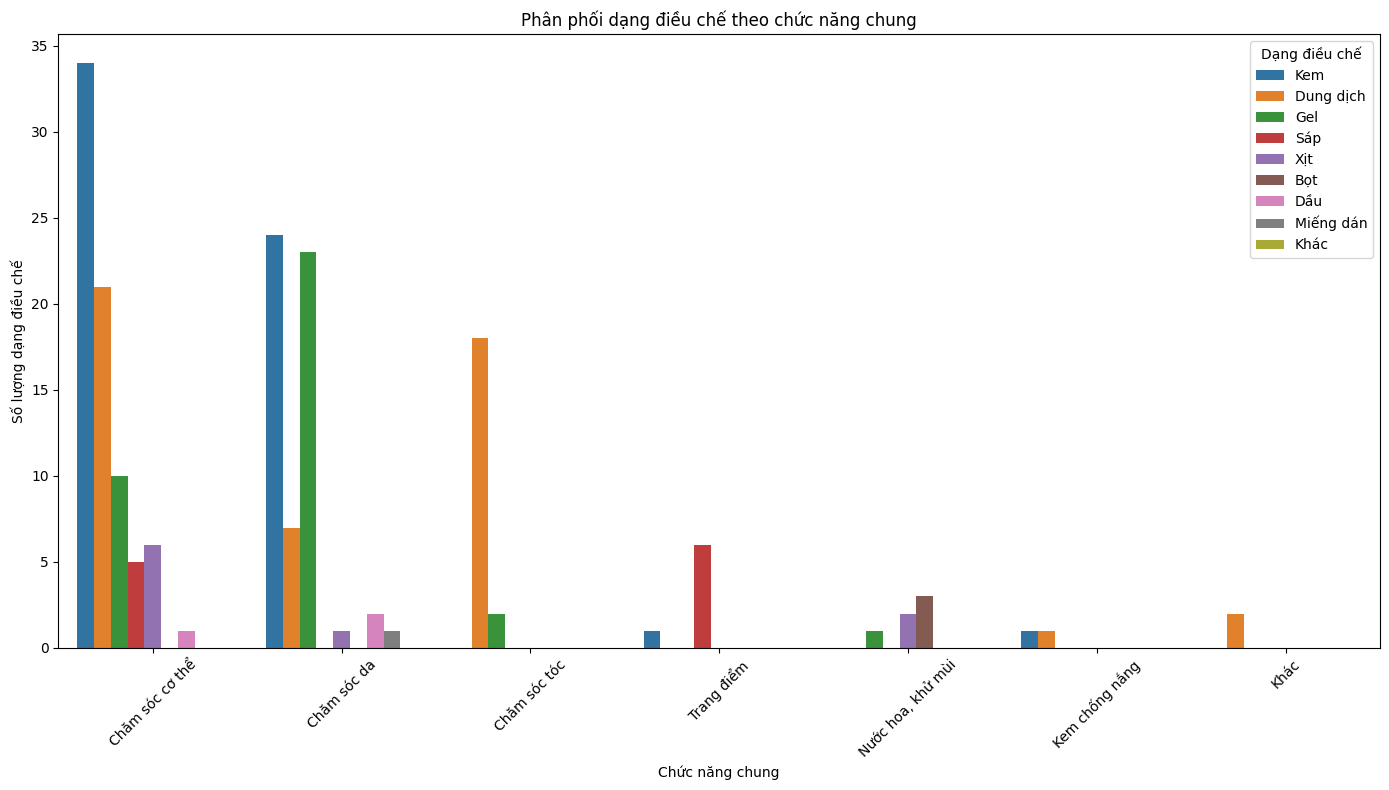

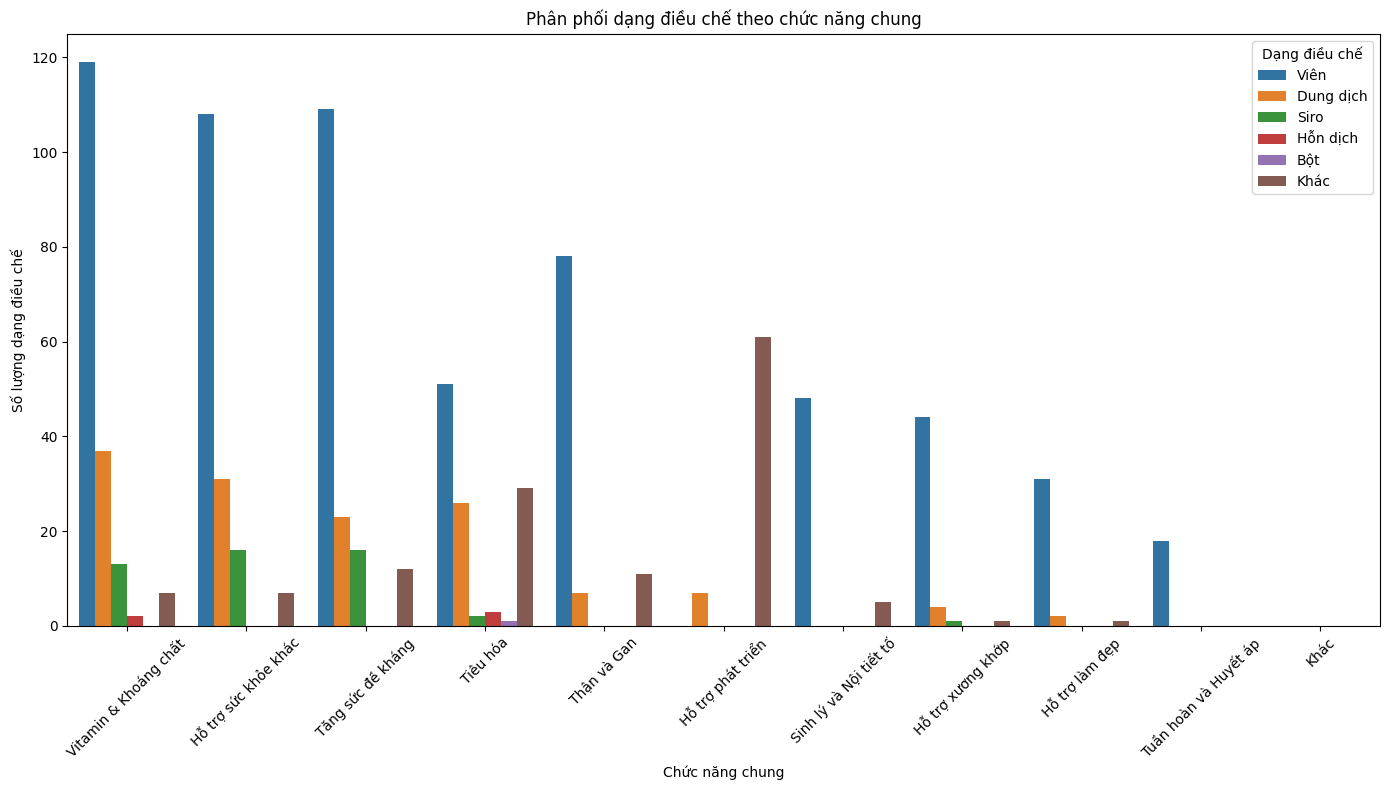

In [ ]:
# Áp dụng phân loại chức năng chung và dạng điều chế chi tiết
df_mypham['General Function'] = df_mypham['Category'].apply(classify_general_function_cosmetics)
df_mypham['General Dosage Form'] = df_mypham['Dosage Form'].apply(classify_general_dosage_form_cosmetics)

df_tpcn['General Function'] = df_tpcn['Category'].apply(classify_general_function_supplements)
df_tpcn['General Dosage Form'] = df_tpcn['Dosage Form'].apply(classify_general_dosage_form_supplements)

# Gọi hàm để vẽ trực quan hóa
visualize_general_function_distribution(df_mypham)
visualize_general_function_distribution(df_tpcn)


1. **Mỹ phẩm**:
   - **Dung dịch**: Phổ biến nhất trong các sản phẩm chăm sóc da do dễ thoa và thẩm thấu nhanh, không gây nhờn.
   - **Gel**: Được ưa chuộng trong sản phẩm chăm sóc da vì kết cấu nhẹ, mát, phù hợp cho da dầu hoặc nhạy cảm.
   - **Bọt** và **Xịt**: Được sử dụng rộng rãi trong chăm sóc cơ thể và tóc do tiện dụng, dễ thoa đều và tiết kiệm thời gian.

2. **Thực phẩm chức năng (TPCN)**:
   - **Viên**: Ưa chuộng nhất trong các danh mục bổ sung sức khỏe hàng ngày nhờ tính dễ sử dụng và bảo quản.
   - **Siro** và **Hỗn dịch**: Phổ biến trong sản phẩm dành cho trẻ em và người khó nuốt viên nén, đặc biệt trong các dòng hỗ trợ miễn dịch và tiêu hóa.

#### Kết luận chung

Người tiêu dùng ưa chuộng các dạng điều chế **dễ sử dụng** và **tiện lợi** phù hợp với thói quen hằng ngày. Trong mỹ phẩm, các dạng **dung dịch** và **gel** chiếm ưu thế vì dễ thoa và không gây nhờn, trong khi **bọt** và **xịt** tiện lợi cho chăm sóc cơ thể và tóc. Đối với thực phẩm chức năng, **viên nén** phổ biến nhất nhờ tính đơn giản và dễ bảo quản, còn **siro** và **hỗn dịch** phù hợp cho trẻ em và người khó nuốt, nhất là trong các sản phẩm hỗ trợ sức khỏe đặc thù.

Từ đó, nhà thuốc Long Châu có thể tập trung vào các dạng dung dịch, gel, bọt, xịt trong mỹ phẩm; viên và siro trong thực phẩm chức năng – ưu tiên các dạng tiện lợi, dễ dùng, để có thể tăng số lượng sản phẩm bán ra và đồng thời còn có thể tăng doanh thu.


## Câu 7: Sự phân bố giá của sản phẩm của các thương hiệu nổi tiếng
Danh mục nào là xu hướng của thị trường mà các thương hiệu hàng đầu đang theo 

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

file_path = 'E:\\Collect_Data_TPCN\\MyPham_TPCN_data.csv'
data = pd.read_csv(file_path)

# Tính tần suất xuất hiện của các thương hiệu và chỉ hiển thị top 20 thương hiệu
top_20_brands_counts = data['Trademark'].value_counts().head(20)

# Vẽ biểu đồ độ phổ biến của các thương hiệu top 20 
plt.figure(figsize=(10, 10))
top_20_brands_counts.plot(kind='barh')
plt.title("Độ phổ biến của các thương hiệu (Top 30)")
plt.xlabel("Số lượng sản phẩm")
plt.ylabel("Thương hiệu")
plt.gca().invert_yaxis()  # Đảo ngược trục y để hiển thị từ nhiều đến ít
plt.tight_layout()
plt.show()

top_20_brands_data = data[data['Trademark'].isin(top_20_brands_counts.index)]

# Bước 5: Đếm số lượng sản phẩm theo danh mục cho từng thương hiệu hàng đầu, sau đó chỉ giữ lại top 10 danh mục phổ biến nhất
category_counts = top_20_brands_data['Category'].value_counts()
top_categories = category_counts.head(10).index
top_brand_category_counts = top_20_brands_data.copy()
top_brand_category_counts['Category'] = top_brand_category_counts['Category'].apply(
    lambda x: x if x in top_categories else 'Khác'
)

# Đếm lại số lượng sản phẩm theo danh mục cho từng thương hiệu hàng đầu sau khi nhóm "Khác"
top_brand_category_counts = top_brand_category_counts.groupby(['Trademark', 'Category']).size().unstack().fillna(0)

# Tạo bảng màu tùy chỉnh với số màu tương ứng với số danh mục
num_categories = top_brand_category_counts.shape[1]
colors = plt.cm.tab20.colors[:num_categories]

# Vẽ biểu đồ sản phẩm phổ biến theo danh mục cho các thương hiệu hàng đầu với bảng màu tùy chỉnh
top_brand_category_counts.plot(kind='bar', stacked=True, figsize=(12, 8), color=colors)
plt.title("Sản phẩm phổ biến theo danh mục (Top 10 + Khác) cho các thương hiệu hàng đầu")
plt.xlabel("Thương hiệu")
plt.ylabel("Số lượng sản phẩm")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Danh mục sản phẩm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'E:\\Collect_Data_TPCN\\MyPham_TPCN_data.csv'

Đầu tiên, để tìm được các thương hiệu được người tin dùng tin tưởng. Chúng ta sẽ tìm 15 thương hiệu xuất hiện nhiều nhất trong danh sách.

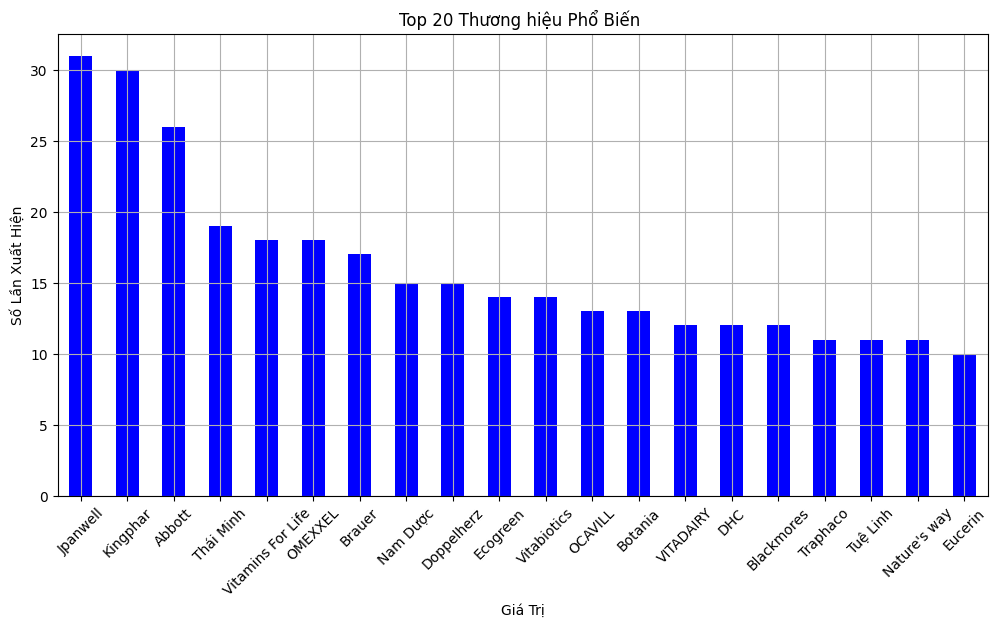

In [ ]:
brand_column = "Trademark"

# Đếm số lần xuất hiện của mỗi giá trị trong cột
value_count = df[brand_column].value_counts()
top10 = value_count.head(20)


plt.figure(figsize=(12, 6)) 
top10.plot(kind='bar', color='blue') 
plt.xlabel("Giá Trị") 
plt.ylabel("Số Lần Xuất Hiện") 
plt.title(f'Top 20 Thương hiệu Phổ Biến ') 
plt.xticks(rotation=45) 
plt.grid(True) 
plt.show()

Sau khi có được top 15 thương hiệu xuất hiện nhiều nhất. Chúng ta sẽ đánh giá sự phân bố giá tiền qua các sản phẩm mà họ bán.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9728\2164767363.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stacked_data = df.groupby([brand_column, 'Price_Range']).size().unstack().fillna(0)


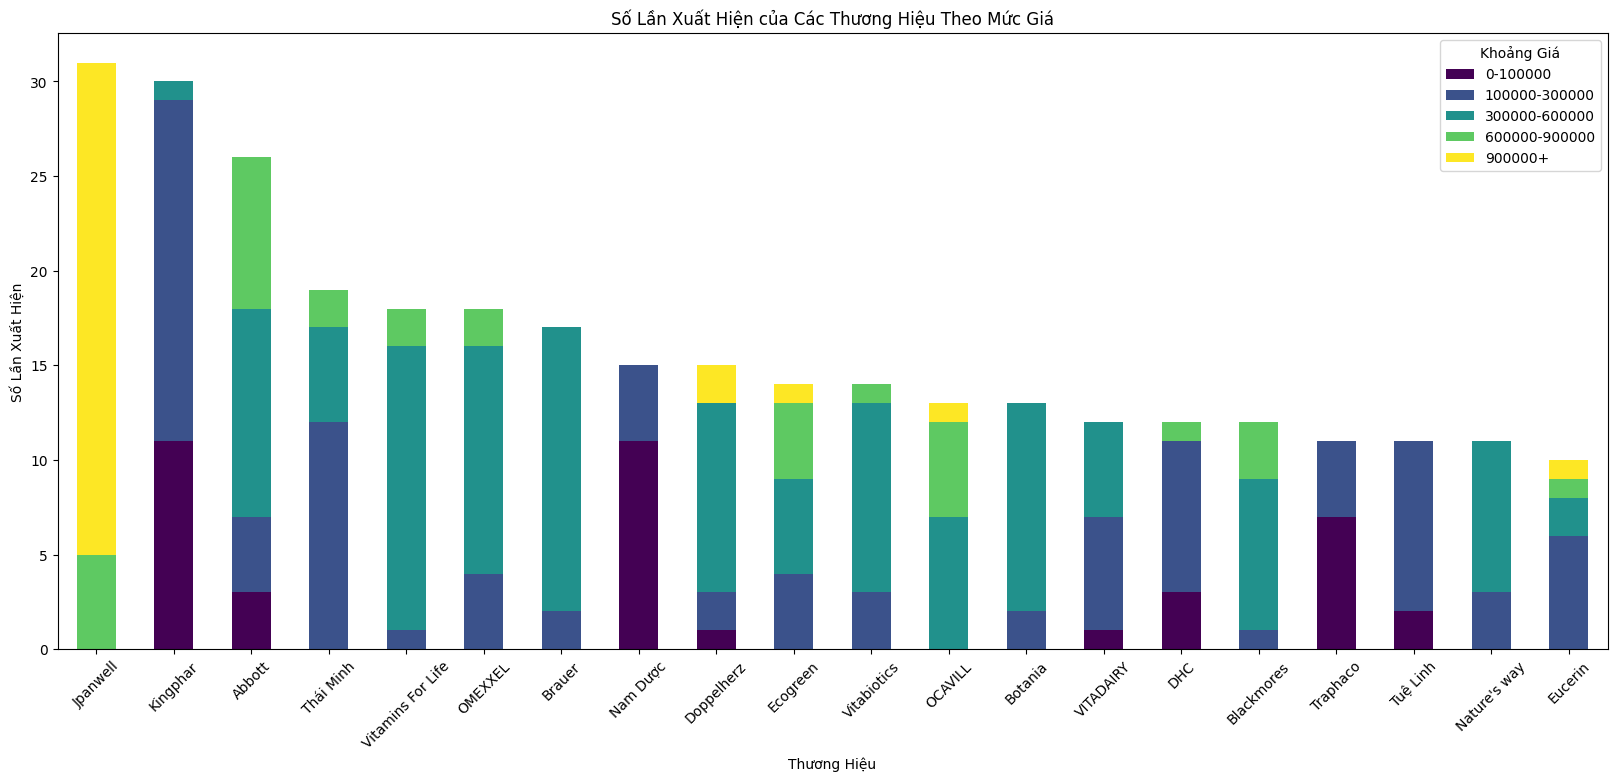

In [ ]:

# Giả sử các cột có tên 'Thuong_Hieu' và 'Gia_Tien'
brand_column = 'Trademark'
price_column = 'Price'

# Xác định các khoảng giá tiền
bins = [0, 100000, 300000, 600000, 900000,  float('inf')]
labels = ['0-100000', '100000-300000', '300000-600000', '600000-900000','900000+']
df['Price_Range'] = pd.cut(df[price_column], bins=bins, labels=labels)

# Đếm số lần xuất hiện của mỗi giá trị trong cột 'Thuong_Hieu' và 'Price_Range'
stacked_data = df.groupby([brand_column, 'Price_Range']).size().unstack().fillna(0)

# Lấy 10 thương hiệu phổ biến nhất
top_20_brands = df[brand_column].value_counts().head(20).index
stacked_data = stacked_data.loc[top_20_brands]

# Tạo biểu đồ cột xếp chồng
stacked_data.plot(kind='bar', stacked=True, figsize=(20, 8), colormap='viridis')
plt.xlabel('Thương Hiệu')
plt.ylabel('Số Lần Xuất Hiện')
plt.title('Số Lần Xuất Hiện của Các Thương Hiệu Theo Mức Giá')
plt.legend(title='Khoảng Giá')
plt.xticks(rotation=45)
plt.show()

In [31]:
processed_df = pd.read_csv("./Data/combined_file_processed.csv")
processed_df.head()

,Product Name,Category,Dosage Form,Price,Trademark,Brand Origin,Country,Rating,Continent,General_function
0,"Gel chấm mụn, mờ thâm Decumar Advance THC 20g ...",Chăm sóc cơ thể,Gel,105000.0,DECUMAR,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
1,Dung dịch vệ sinh vùng kín Bimunica 250ml dành...,Chăm sóc cơ thể,Dạng kem,230000.0,Eucerin,Hoa Kỳ,Liên Bang Nga,5.0,Europe,Chăm sóc cơ thể
2,"Kem giảm thâm vùng nách, mông, bikini Neothera...",Chăm sóc cơ thể,Dạng kem,139000.0,La Beauty,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể
3,Gel rửa mặt SVR Sebiaclear Gel Moussant 200ml ...,Chăm sóc cơ thể,Dạng kem,390000.0,SVR,Pháp,Pháp,5.0,Europe,Chăm sóc cơ thể
4,Bọt vệ sinh nam giới Sumely Men's Sanitary Foa...,"Lăn khử mùi, xịt khử mùi",Dạng bọt,96000.0,Eucerin,Việt Nam,Việt Nam,5.0,Asia,Chăm sóc cơ thể


<Figure size 1200x800 with 0 Axes>

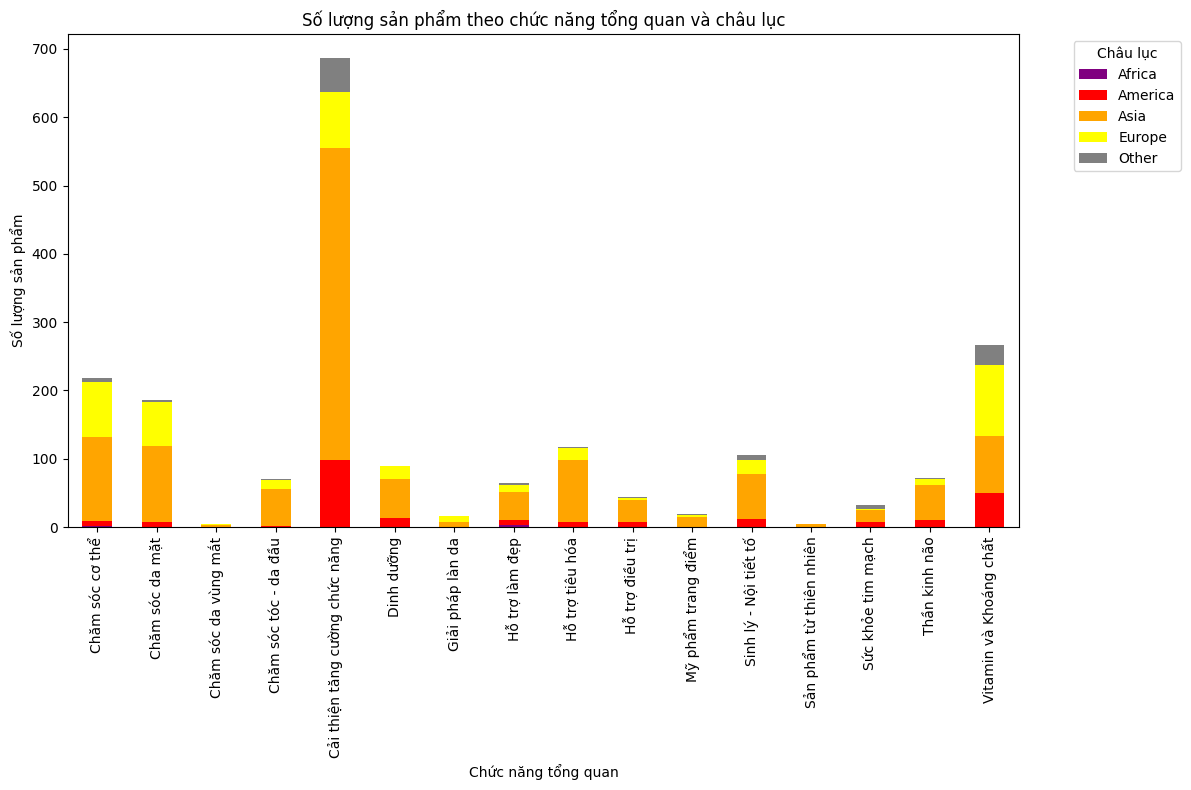

In [32]:
# Grouping data to calculate the count of products by General_function and Continent
function_continent_counts = processed_df.groupby(['General_function', 'Continent']).size().unstack(fill_value=0)


custom_colors = ["purple", "red", "orange", "yellow", "grey"]

plt.figure(figsize=(12, 8))
function_continent_counts.plot(kind='bar', stacked=True, color=custom_colors, figsize=(12, 8))
plt.title("Số lượng sản phẩm theo chức năng tổng quan và châu lục")
plt.xlabel("Chức năng tổng quan")
plt.ylabel("Số lượng sản phẩm")
plt.legend(title="Châu lục", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

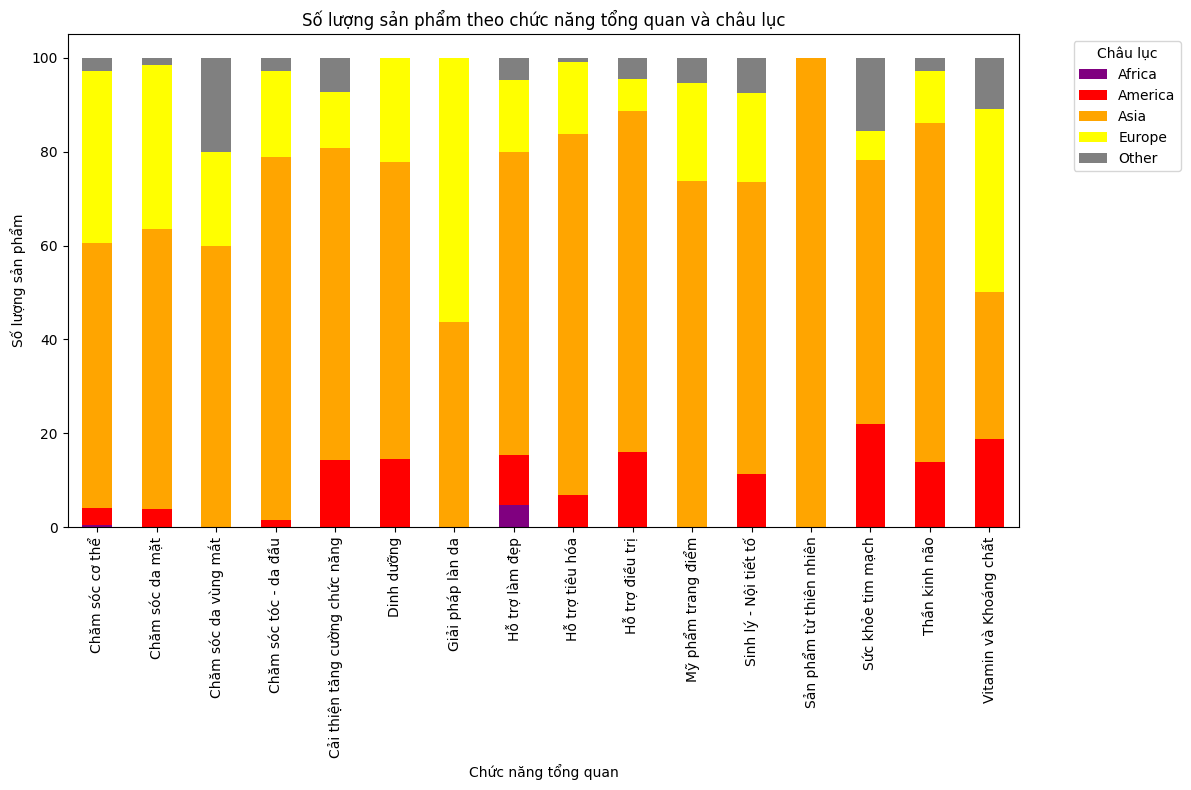

In [33]:
# Grouping data to calculate the count of products by General_function and Continent
function_continent_counts = processed_df.groupby(['General_function', 'Continent']).size().unstack(fill_value=0)

function_continent_percent = function_continent_counts.div(function_continent_counts.sum(axis=1), axis=0) * 100

custom_colors = ["purple", "red", "orange", "yellow", "grey"]

plt.figure(figsize=(12, 8))
function_continent_percent.plot(kind='bar', stacked=True, color=custom_colors, figsize=(12, 8))
plt.title("Số lượng sản phẩm theo chức năng tổng quan và châu lục")
plt.xlabel("Chức năng tổng quan")
plt.ylabel("Số lượng sản phẩm")
plt.legend(title="Châu lục", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

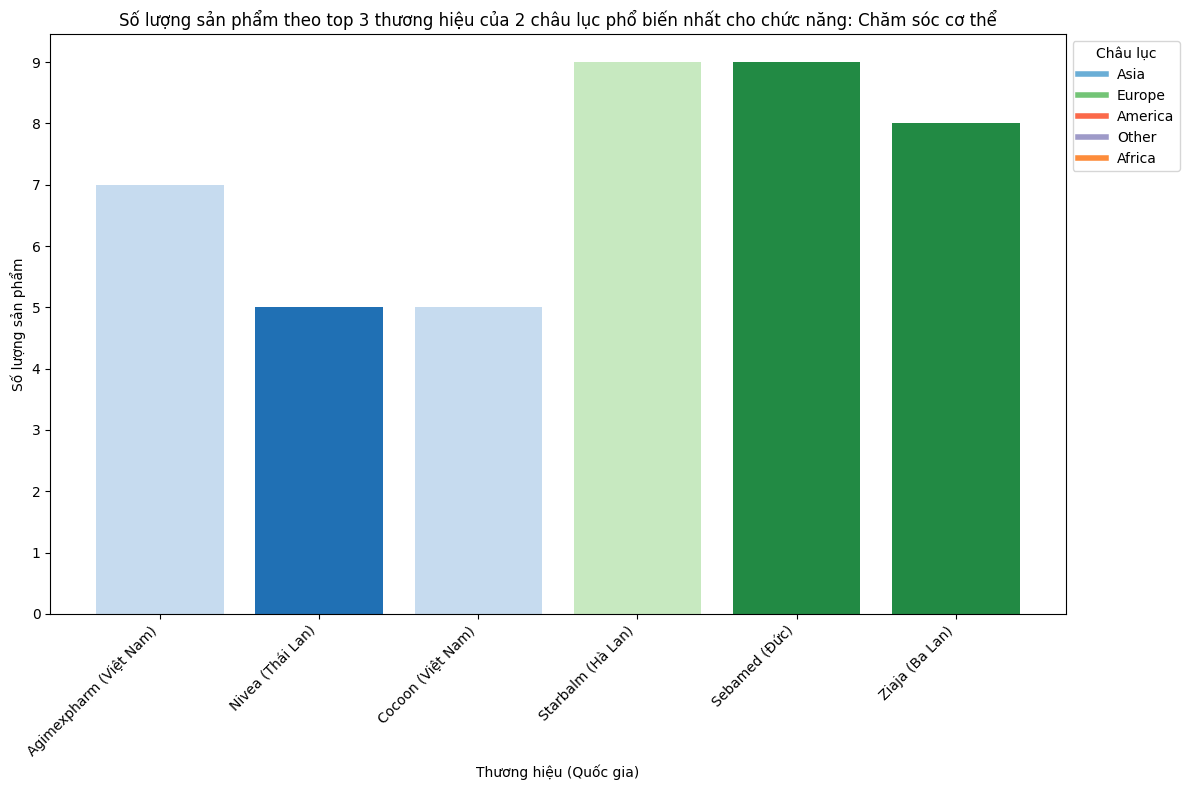

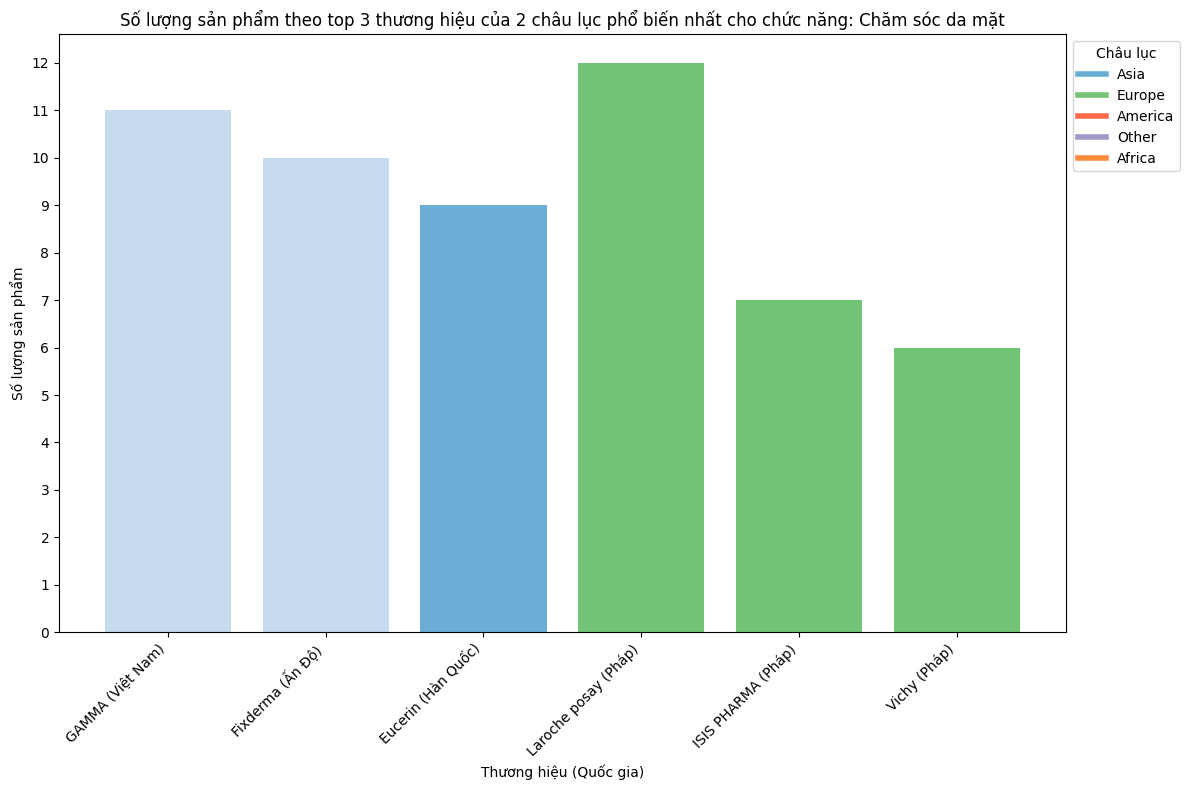

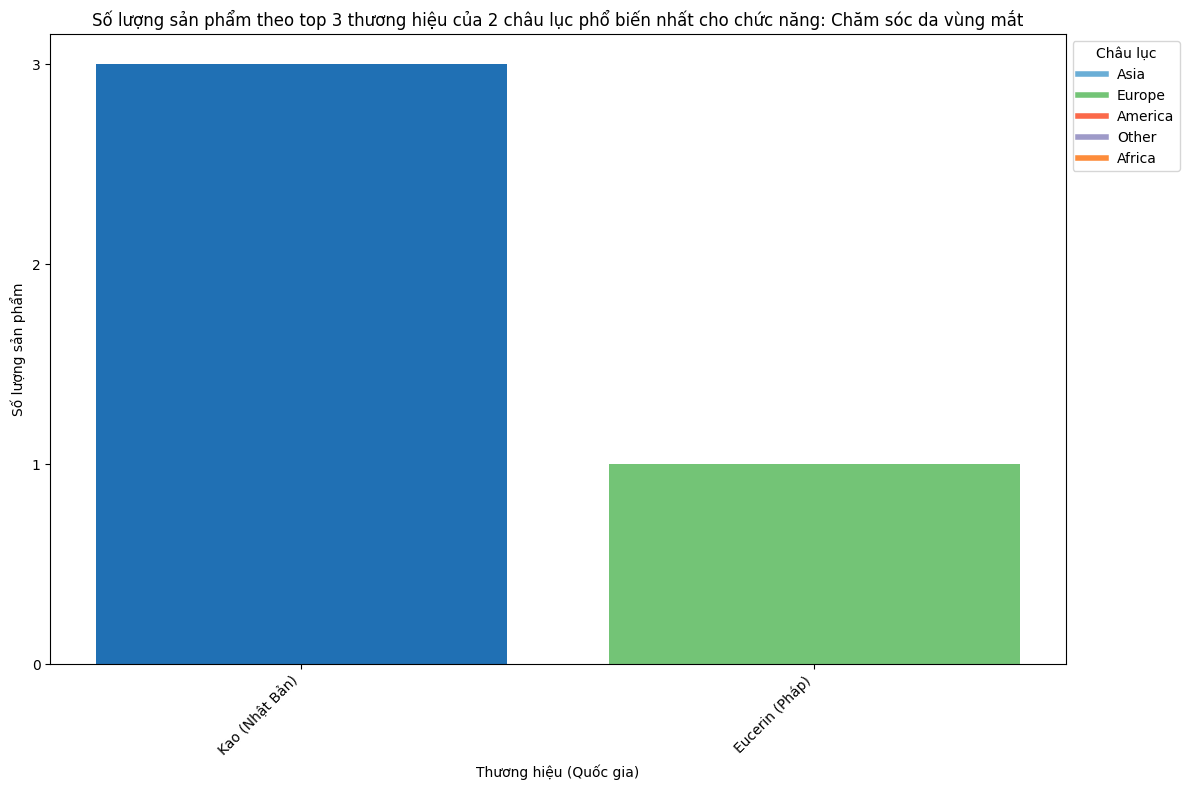

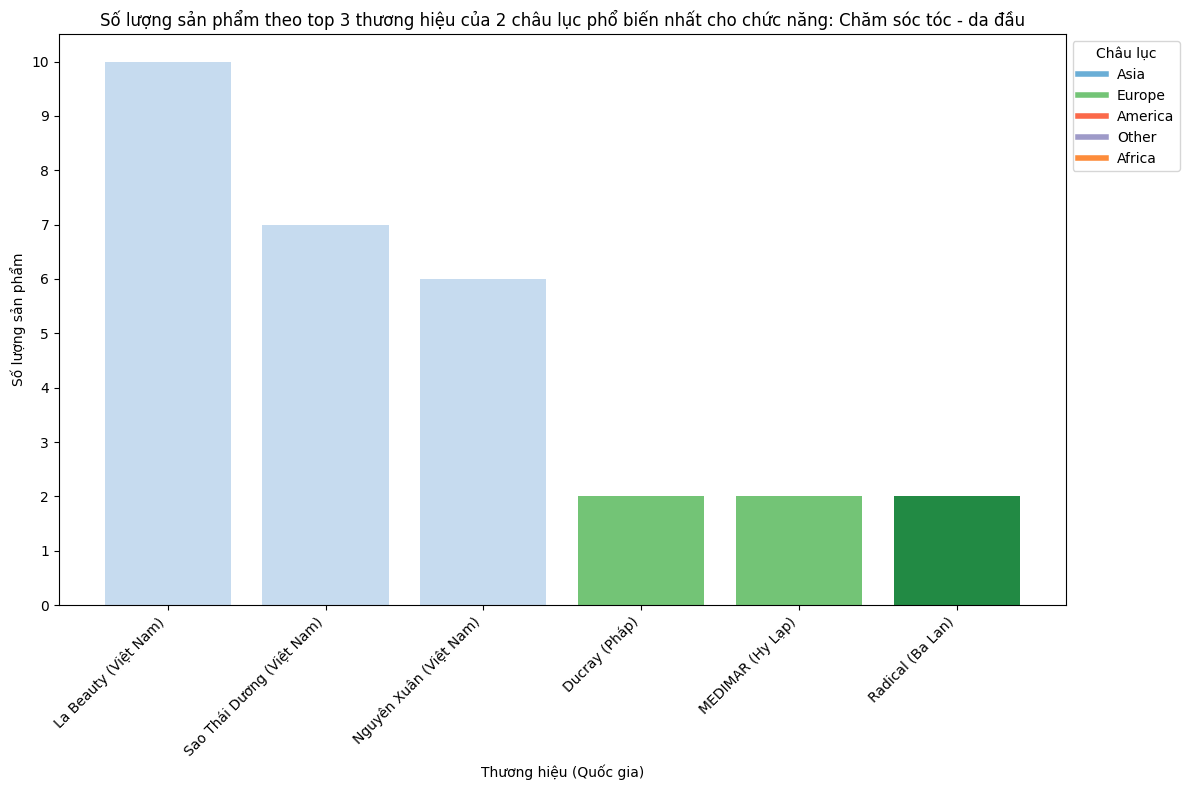

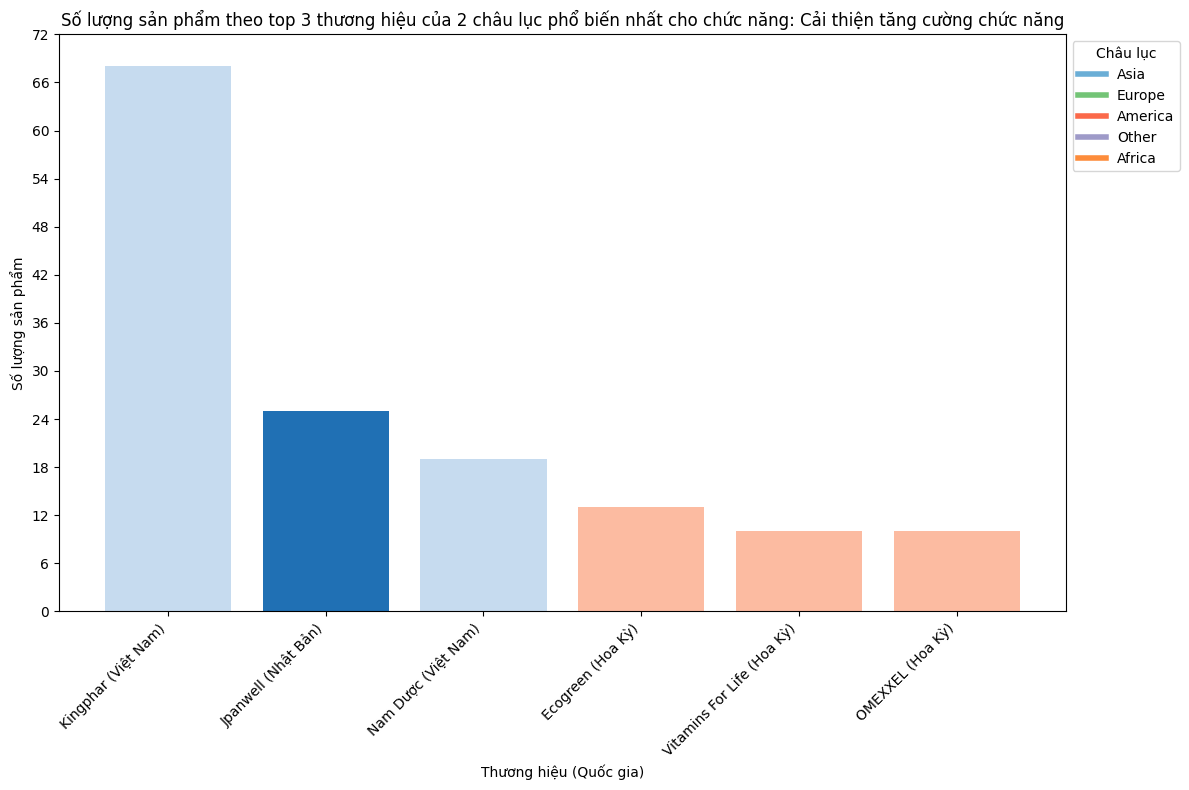

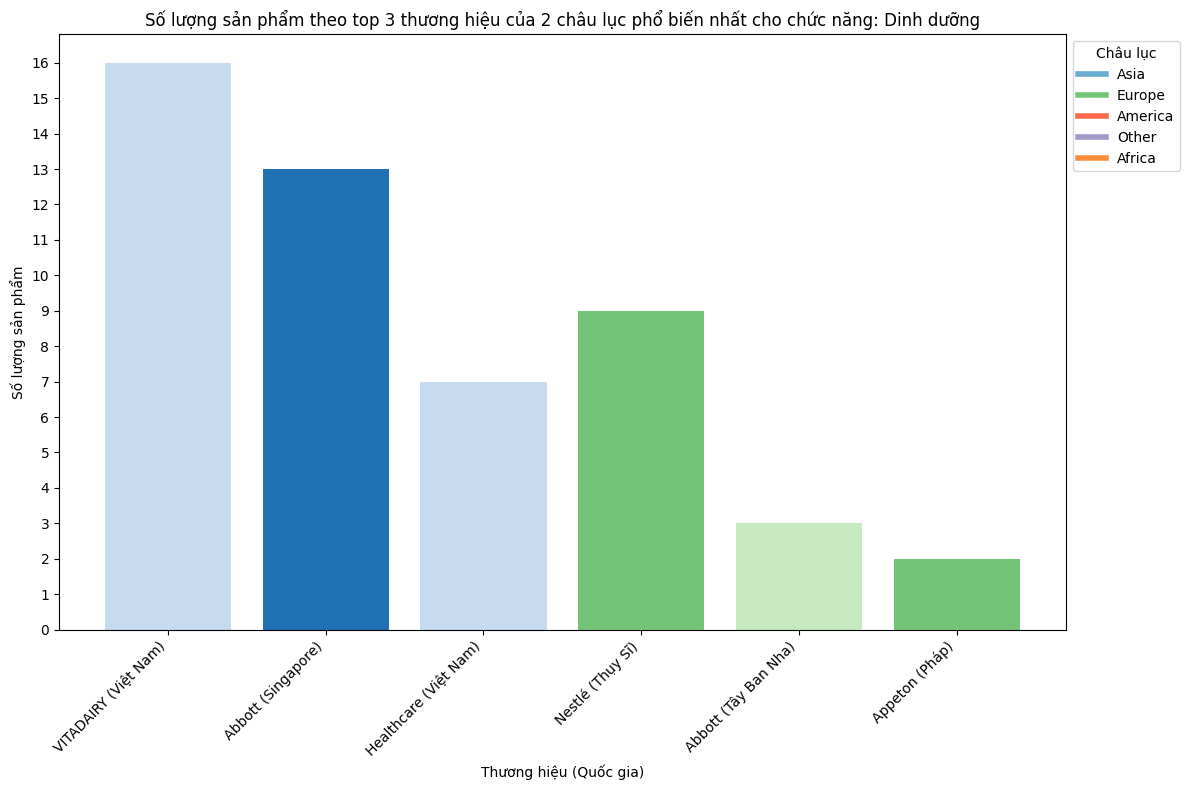

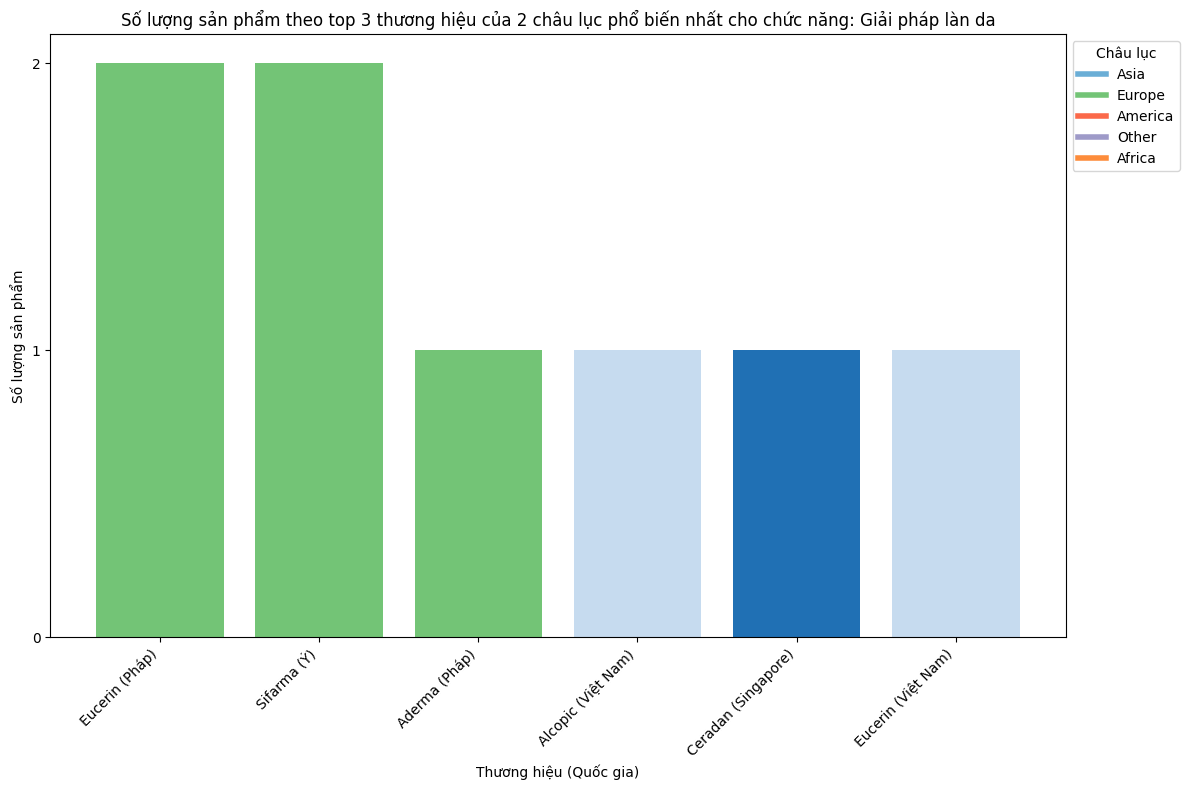

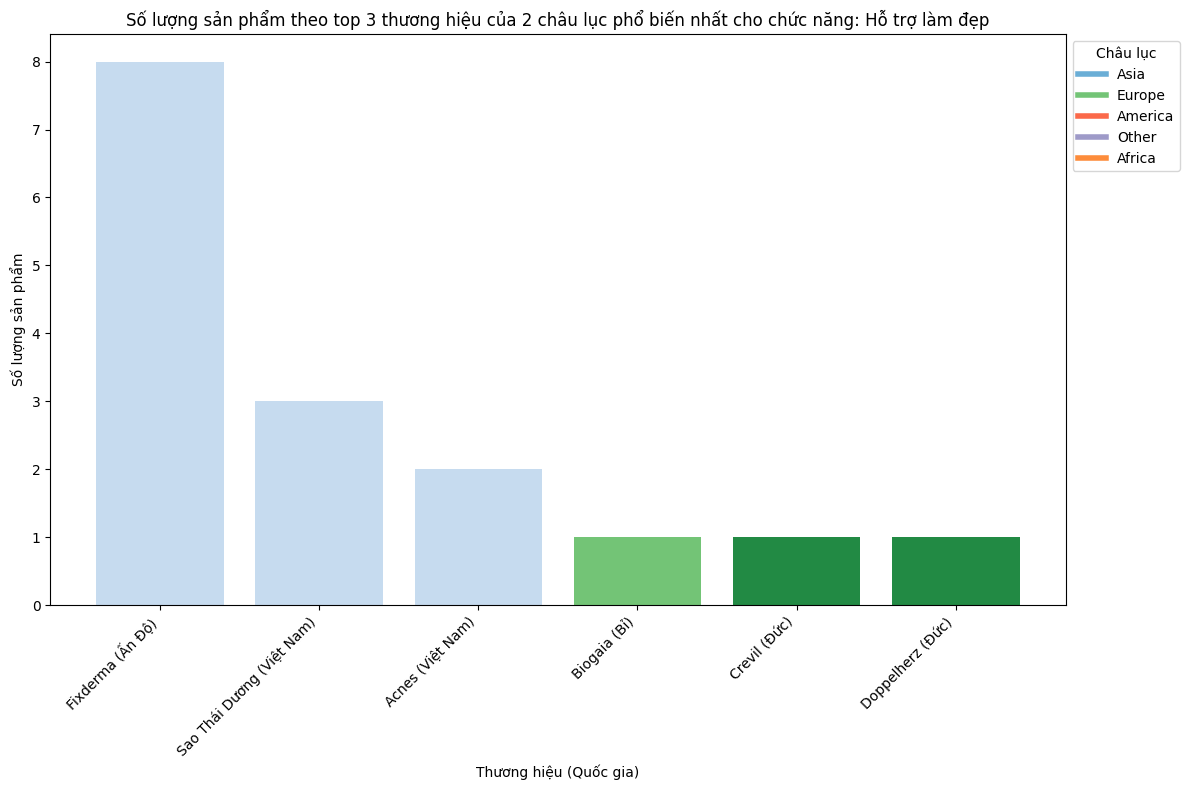

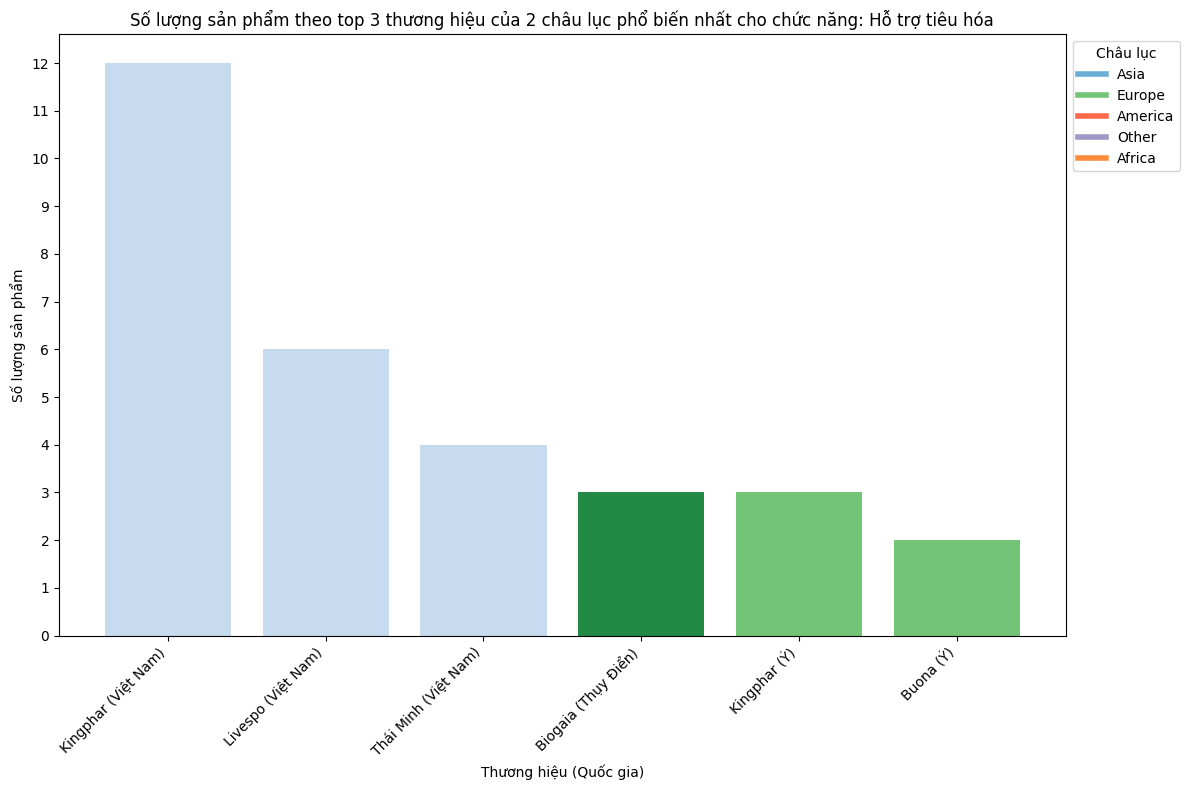

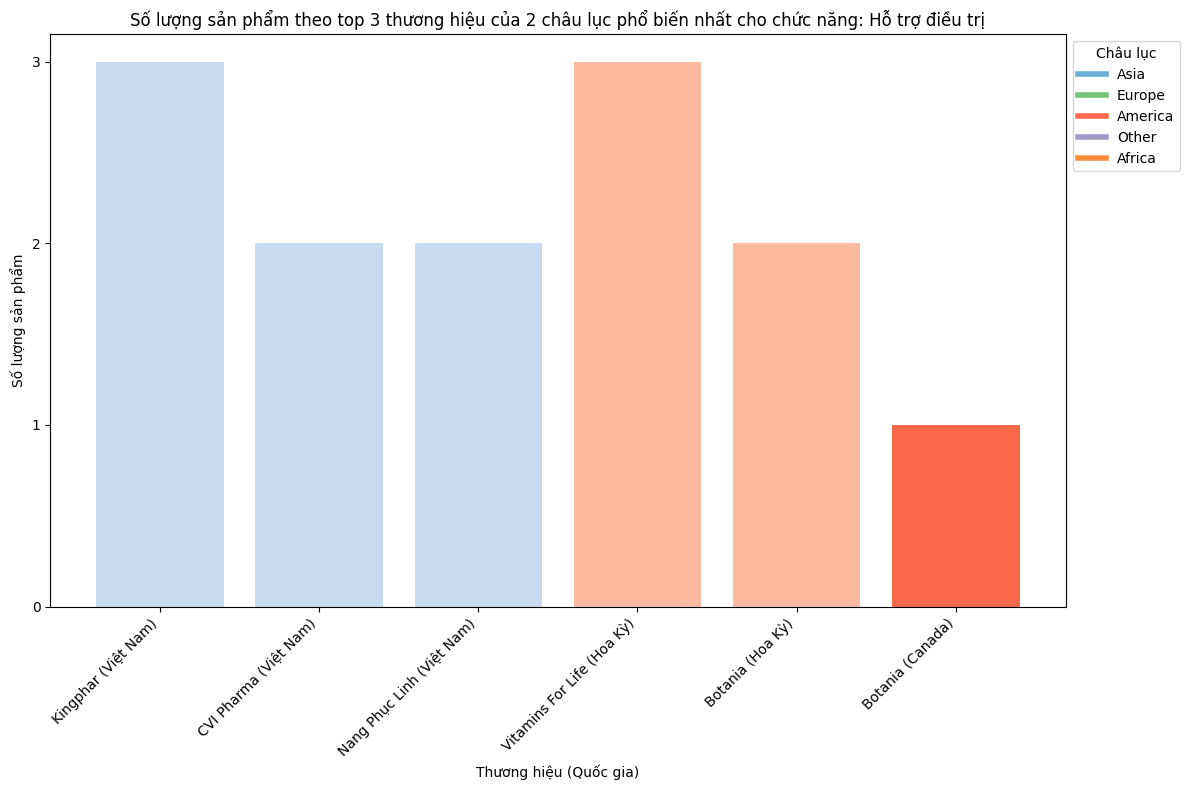

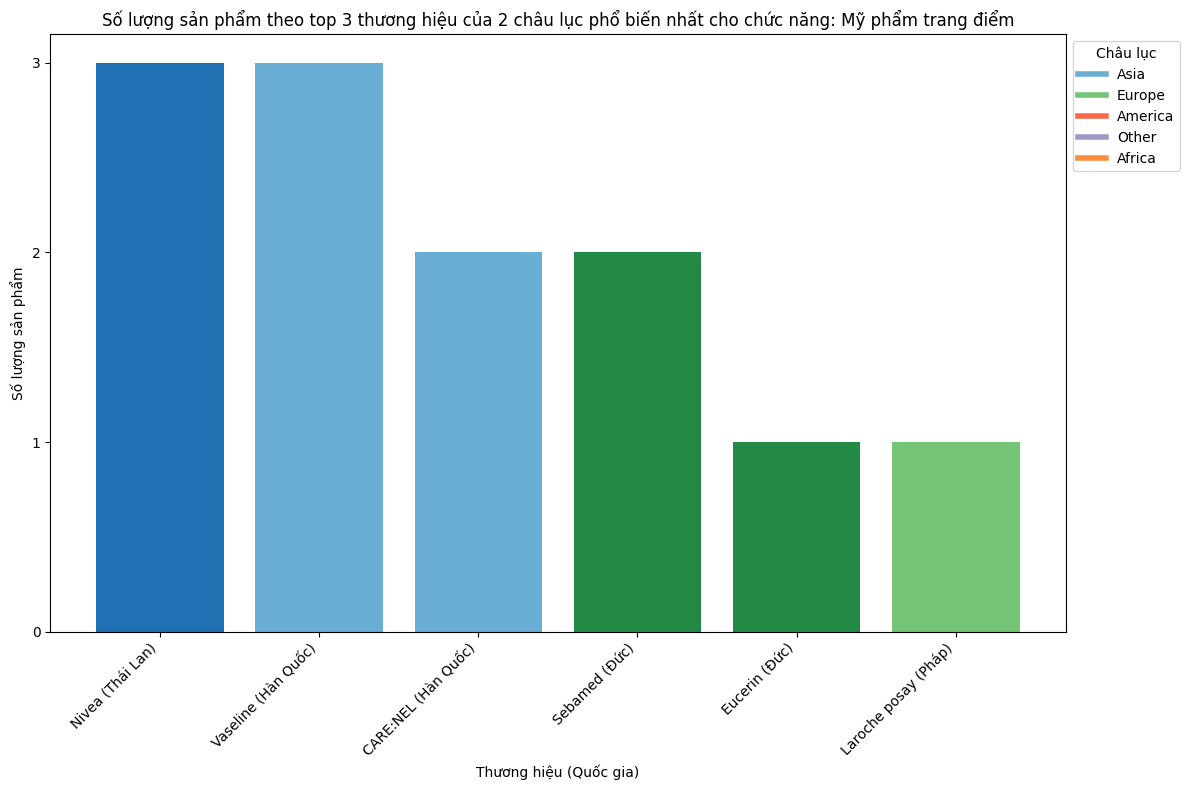

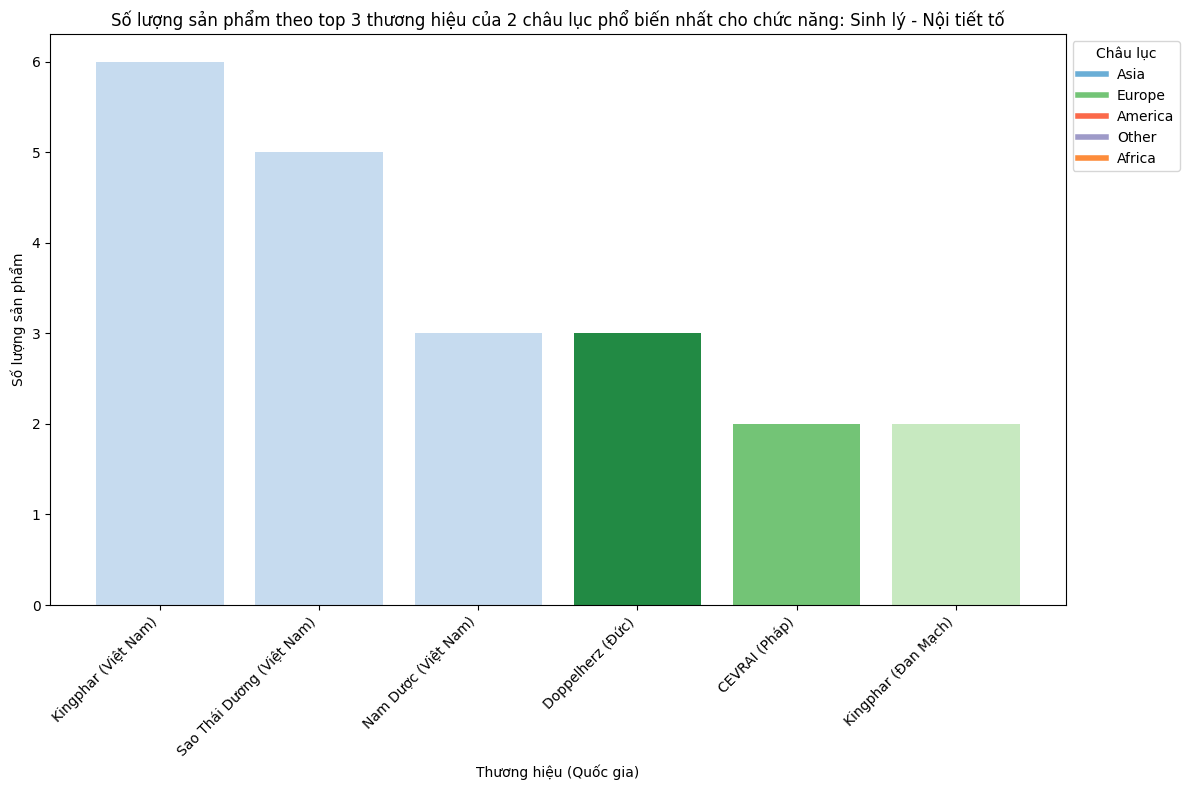

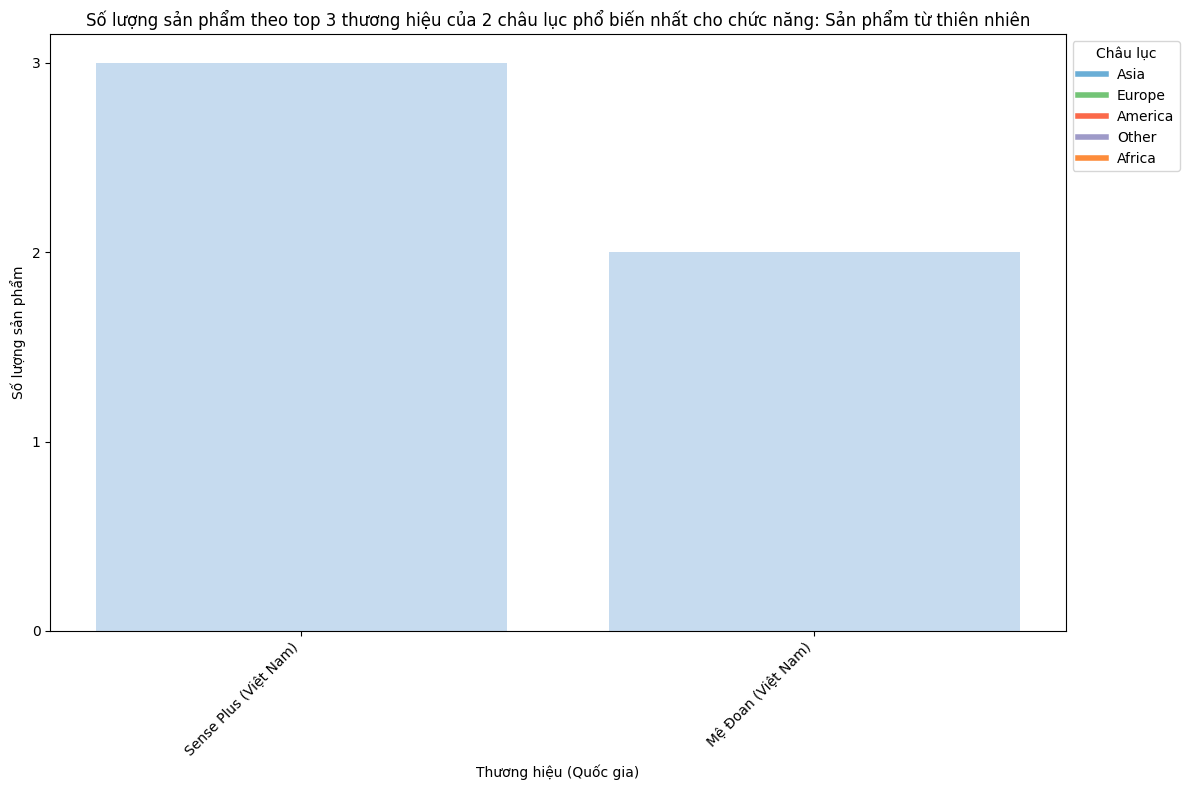

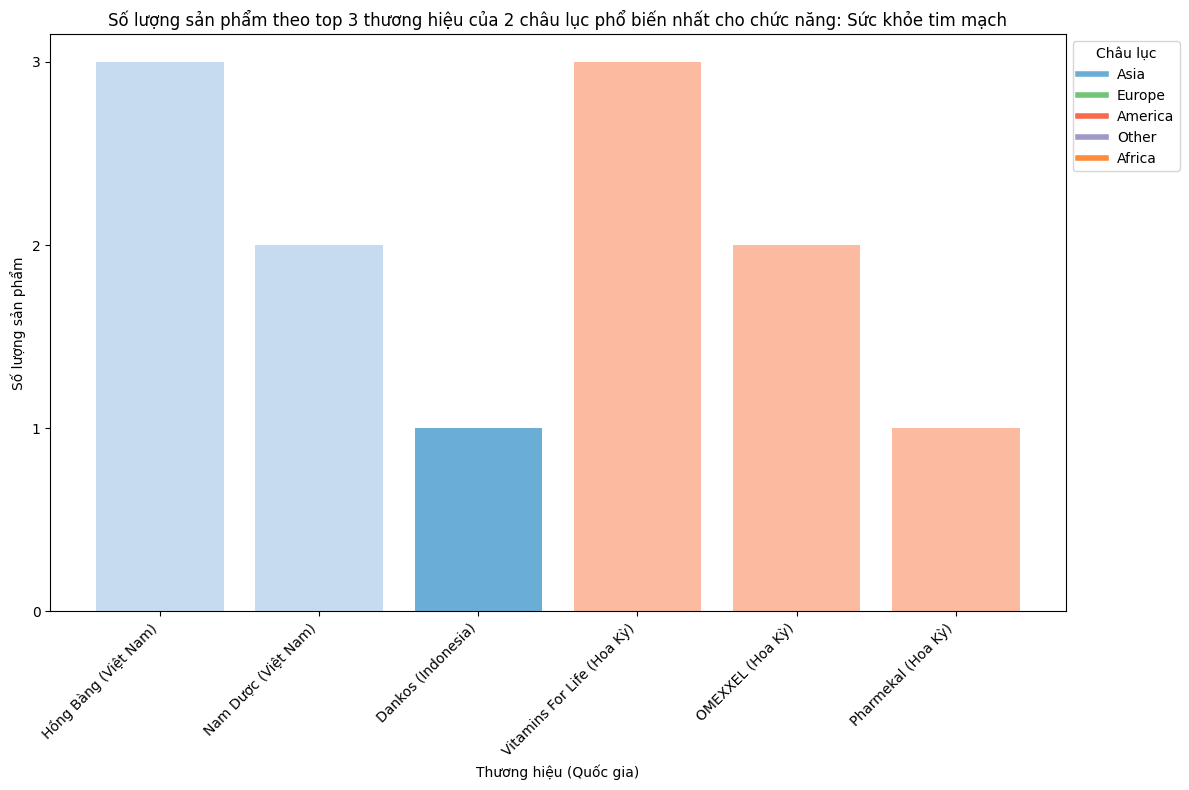

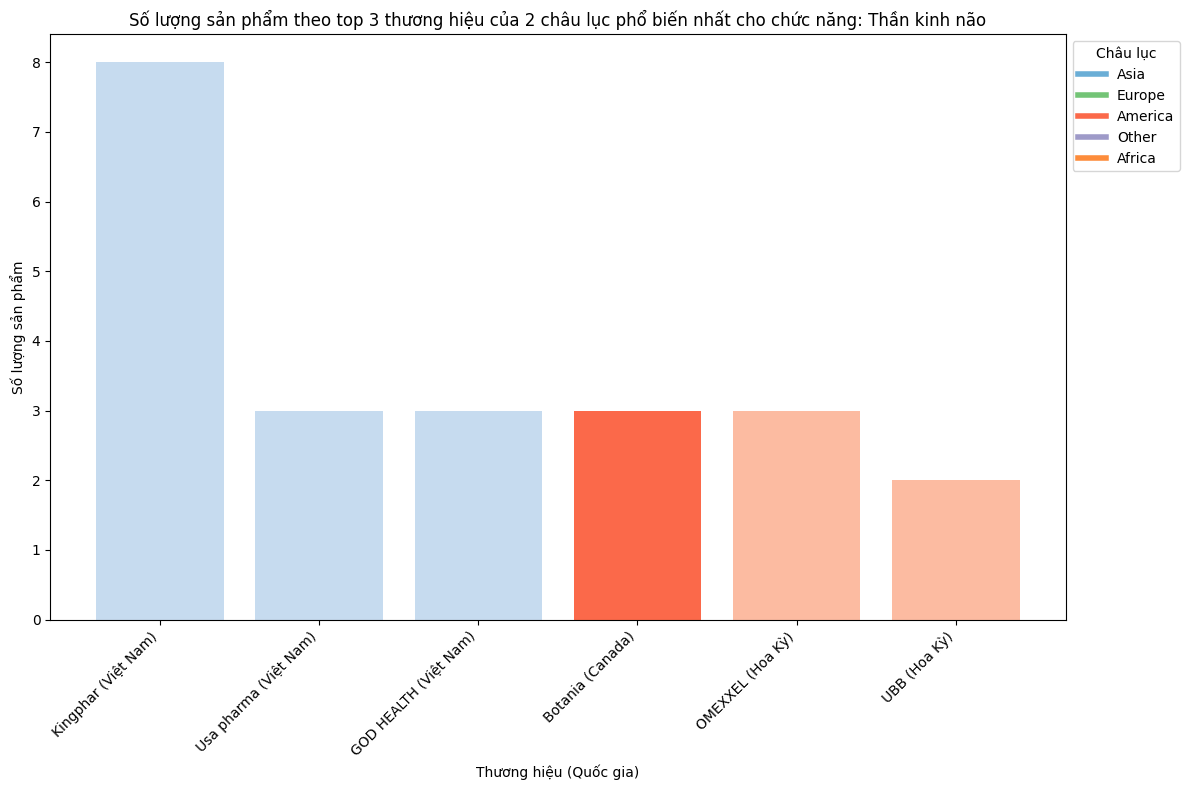

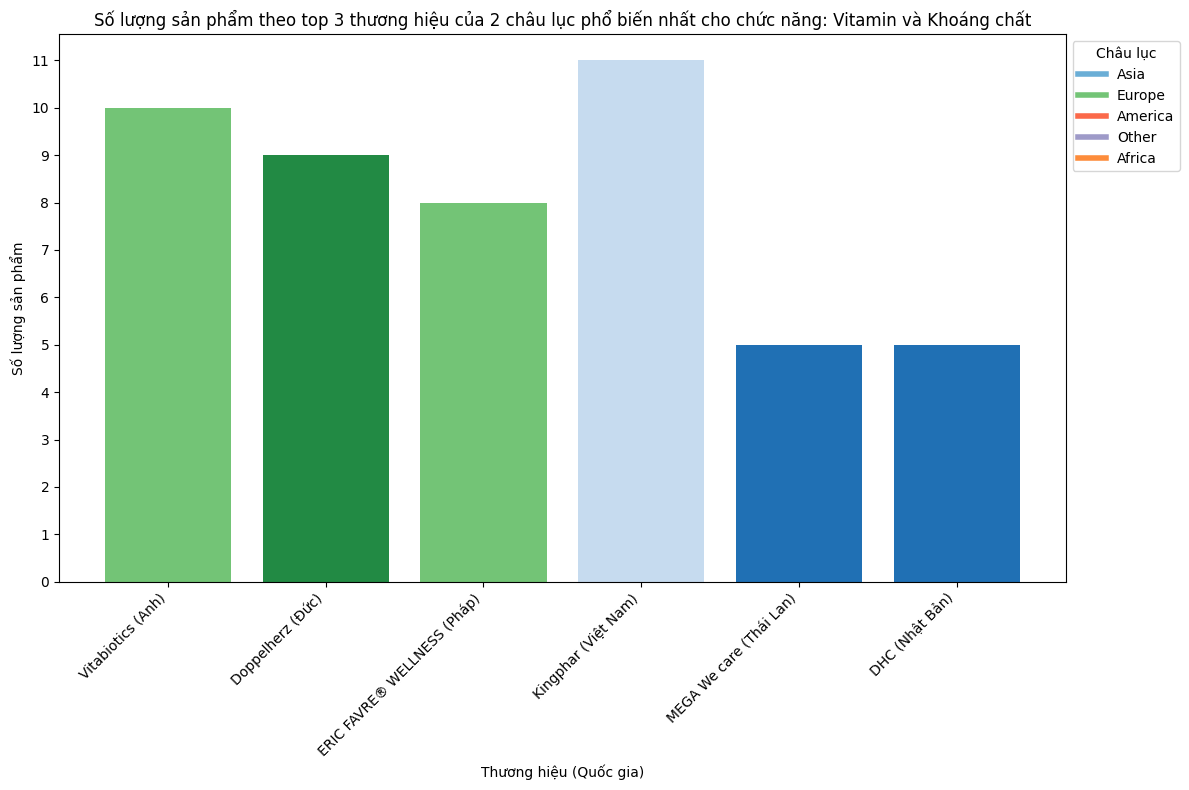

In [34]:
# Chọn ra 2 châu lục có số lượng sản phẩm lớn nhất cho từng General_function
top_continents_per_function = (
    processed_df.groupby(['General_function', 'Continent'])
    .size()
    .reset_index(name='Product_Count')
    .sort_values(['General_function', 'Product_Count'], ascending=[True, False])
    .groupby('General_function')
    .head(2)
)


# Chọn top 3 thương hiệu nổi tiếng từ mỗi châu lục (trong top 2 châu lục vừa chọn)
top_trademarks_per_continent = []
for _, row in top_continents_per_function.iterrows():
    general_function = row['General_function']
    continent = row['Continent']
    
    top_trademarks = (
        processed_df[(processed_df['General_function'] == general_function) & (processed_df['Continent'] == continent)]
        .groupby(['Trademark', 'Country'])  
        .size()
        .reset_index(name='Product_Count')
        .sort_values('Product_Count', ascending=False)
        .head(3)
    )
    
    top_trademarks['General_function'] = general_function
    top_trademarks['Continent'] = continent
    top_trademarks_per_continent.append(top_trademarks)

# Gộp danh sách các dataframe thành một dataframe
top_3_trademarks_per_group = pd.concat(top_trademarks_per_continent, ignore_index=True)


# Vẽ biểu đồ cột cho từng General_function với nhãn thương hiệu và quốc gia
unique_functions_new = top_3_trademarks_per_group['General_function'].unique()


# Tạo bảng màu cho mỗi châu lục
continent_palettes_adjusted = {
    'Asia': sns.color_palette("Blues", n_colors=3),
    'Europe': sns.color_palette("Greens", n_colors=3),
    'America': sns.color_palette("Reds", n_colors=3),
    'Africa': sns.color_palette("Oranges", n_colors=3),
    'Other': sns.color_palette("Purples", n_colors=3)
}


# Tạo dictionary màu sắc cho từng quốc gia trong mỗi châu lục
unique_continents = processed_df['Continent'].unique()
country_colors_adjusted = {
    country: continent_palettes_adjusted[continent][i % 3]
    for continent in unique_continents
    for i, country in enumerate(processed_df[processed_df['Continent'] == continent]['Country'].unique())
}


# Vẽ biểu đồ cho từng General_function
for function in unique_functions_new:
    # Lọc dữ liệu cho chức năng cụ thể
    function_data = top_3_trademarks_per_group[top_3_trademarks_per_group['General_function'] == function]
    
    # Thiết lập nhãn cho biểu đồ (bao gồm tên thương hiệu và quốc gia)
    labels = function_data.apply(lambda row: f"{row['Trademark']} ({row['Country']})", axis=1)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(12, 8))
    bar_colors = [country_colors_adjusted.get(country, 'grey') for country in function_data['Country']]
    plt.bar(labels, function_data['Product_Count'], color=bar_colors)
    plt.title(f"Số lượng sản phẩm theo top 3 thương hiệu của 2 châu lục phổ biến nhất cho chức năng: {function}")
    plt.xlabel("Thương hiệu (Quốc gia)")
    plt.ylabel("Số lượng sản phẩm")
    plt.xticks(rotation=45, ha='right')
    
    max_value = function_data['Product_Count'].max()
    step = max(1, max_value // 10) 
    plt.yticks(range(0, max_value + step, step))

    # Thêm chú thích cho màu sắc châu lục
    legend_elements = [
        plt.Line2D([0], [0], color=continent_palettes_adjusted[continent][1], lw=4, label=continent)
        for continent in unique_continents
    ]
    plt.legend(handles=legend_elements, title="Châu lục", loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()
